# Lending Club Loan — Full Preprocessing Pipeline
Data Mining Project | Preprocessing Phase

---
## Dua Dataset yang Digunakan

| Dataset | File | Baris | Kolom | Deskripsi |
|---|---|---|---|---|
| `df_acc` | accepted_2007_to_2018Q4.csv | ~2.26 juta | 151 | Pinjaman yang diterima |
| `df_rej` | rejected_2007_to_2018Q4.csv | ~27.6 juta | 9 | Pinjaman yang ditolak |

Strategi pipeline:
df_acc diproses secara penuh (EDA, Cleaning, Transform, Feature Selection) karena memiliki
banyak fitur dan target label loan_status.
df_rej diproses secara terpisah dengan pipeline lebih sederhana, lalu digabung untuk analisis komparatif.
Keduanya digabung menjadi df_combined sebagai clean final dataset.

---
# Setup — Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Library berhasil diimport')

Library berhasil diimport


---
# Load Data — Membaca Kedua CSV

In [2]:
# low_memory=False agar pandas membaca seluruh kolom sekaligus
# untuk inferensi tipe yang akurat pada kolom dengan tipe campuran

df_acc = pd.read_csv(
    '../Datasets/Raw/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv',
    low_memory=False
)
print(f'df_acc: {df_acc.shape[0]:,} baris x {df_acc.shape[1]} kolom')

df_rej = pd.read_csv(
    '../Datasets/Raw/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv',
    low_memory=False
)
print(f'df_rej: {df_rej.shape[0]:,} baris x {df_rej.shape[1]} kolom')

df_acc: 2,260,701 baris x 151 kolom
df_rej: 27,648,741 baris x 9 kolom


---
# Langkah 1 — Exploratory Data Analysis (EDA)

Tujuan: Kenali data sebelum menyentuhnya. Pahami struktur, distribusi, dan masalah kualitas data.

## 1.1 — Struktur Data

In [3]:
print('RINGKASAN df_acc (ACCEPTED LOANS)')
print(f'Jumlah baris  : {df_acc.shape[0]:,}')
print(f'Jumlah kolom  : {df_acc.shape[1]}')
print(f'Memory usage  : {df_acc.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print()
print('Tipe data:')
print(df_acc.dtypes.value_counts())
df_acc.head()

RINGKASAN df_acc (ACCEPTED LOANS)
Jumlah baris  : 2,260,701
Jumlah kolom  : 151
Memory usage  : 6.28 GB

Tipe data:
float64    113
object      38
Name: count, dtype: int64


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,...,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.00,35000.00,35000.00,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.00,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.06,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.00,10400.00,10400.00,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.00,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.37,...,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print('RINGKASAN df_rej (REJECTED LOANS)')
print(f'Jumlah baris  : {df_rej.shape[0]:,}')
print(f'Jumlah kolom  : {df_rej.shape[1]}')
print(f'Memory usage  : {df_rej.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print()
print('Tipe data:')
print(df_rej.dtypes.value_counts())
df_rej.head()

RINGKASAN df_rej (REJECTED LOANS)
Jumlah baris  : 27,648,741
Jumlah kolom  : 9
Memory usage  : 10.00 GB

Tipe data:
object     6
float64    3
Name: count, dtype: int64


,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,1000.00,2007-05-26,Wedding Covered but No Honeymoon,693.00,10%,481xx,NM,4 years,0.00
1,1000.00,2007-05-26,Consolidating Debt,703.00,10%,010xx,MA,< 1 year,0.00
2,11000.00,2007-05-27,Want to consolidate my debt,715.00,10%,212xx,MD,1 year,0.00
3,6000.00,2007-05-27,waksman,698.00,38.64%,017xx,MA,< 1 year,0.00
4,1500.00,2007-05-27,mdrigo,509.00,9.43%,209xx,MD,< 1 year,0.00


## 1.2 — Analisis Missing Values

In [5]:
def missing_report(df, name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': pct,
        'Dtype': df.dtypes
    })
    report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'Missing Value Report — {name}')
    print(f'Total kolom dengan missing : {len(report)} dari {df.shape[1]}')
    print(f'Kolom dengan >50% missing  : {(report["Missing %"] > 50).sum()}')
    print(f'Kolom dengan >90% missing  : {(report["Missing %"] > 90).sum()}')
    return report

In [6]:
missing_acc = missing_report(df_acc, 'df_acc')
print('\nTop 20 kolom dengan missing terbanyak:')
missing_acc.head(20)

Missing Value Report — df_acc
Total kolom dengan missing : 150 dari 151
Kolom dengan >50% missing  : 44
Kolom dengan >90% missing  : 38

Top 20 kolom dengan missing terbanyak:


,Missing Count,Missing %,Dtype
member_id,2260701,100.00,float64
orig_projected_additional_accrued_interest,2252050,99.62,float64
hardship_payoff_balance_amount,2249784,99.52,float64
hardship_last_payment_amount,2249784,99.52,float64
payment_plan_start_date,2249784,99.52,object
hardship_type,2249784,99.52,object
hardship_status,2249784,99.52,object
hardship_start_date,2249784,99.52,object
deferral_term,2249784,99.52,float64
hardship_amount,2249784,99.52,float64


In [7]:
missing_rej = missing_report(df_rej, 'df_rej')
print('\nSemua kolom missing di df_rej:')
missing_rej

Missing Value Report — df_rej
Total kolom dengan missing : 6 dari 9
Kolom dengan >50% missing  : 1
Kolom dengan >90% missing  : 0

Semua kolom missing di df_rej:


,Missing Count,Missing %,Dtype
Risk_Score,18497630,66.90,float64
Employment Length,951355,3.44,object
Loan Title,1305,0.00,object
Zip Code,293,0.00,object
State,22,0.00,object
Policy Code,918,0.00,float64


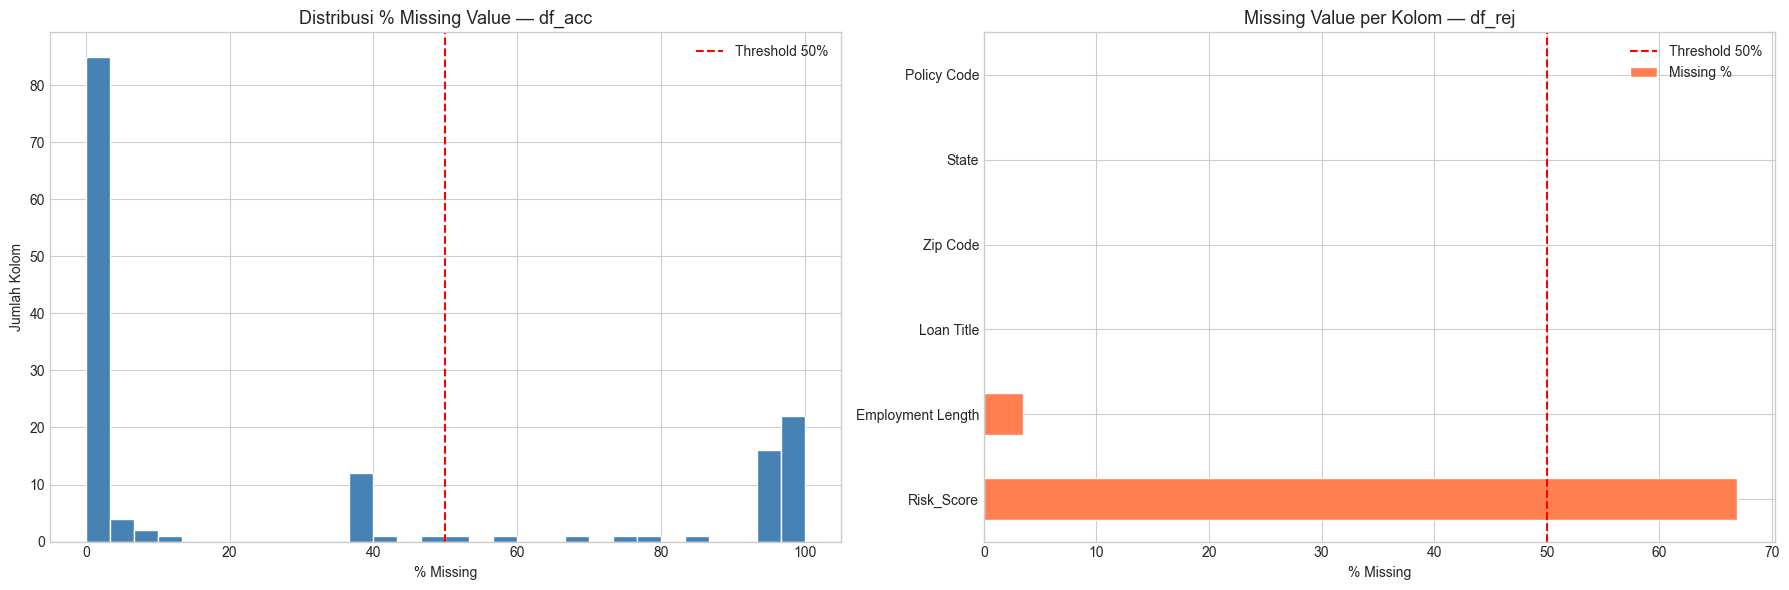

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

missing_acc['Missing %'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi % Missing Value — df_acc', fontsize=13)
axes[0].set_xlabel('% Missing')
axes[0].set_ylabel('Jumlah Kolom')
axes[0].axvline(x=50, color='red', linestyle='--', label='Threshold 50%')
axes[0].legend()

if len(missing_rej) > 0:
    missing_rej['Missing %'].plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
    axes[1].set_title('Missing Value per Kolom — df_rej', fontsize=13)
    axes[1].set_xlabel('% Missing')
    axes[1].axvline(x=50, color='red', linestyle='--', label='Threshold 50%')
    axes[1].legend()

plt.tight_layout()
plt.savefig('Results/Images/missing_value_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Missing Value Analysis:

Histogram df_acc menunjukkan distribusi right-skewed — mayoritas kolom memiliki missing
rendah di bawah 10%, namun ada ekor panjang ke kanan berupa kolom dengan missing sangat
tinggi di atas 80%. Kolom-kolom tersebut (hardship, settlement, dll) akan di-drop karena
tidak bisa diimputasi secara andal.

Bar chart df_rej menunjukkan Risk_Score memiliki missing di atas 50% dan menjadi kandidat
drop utama. Dataset df_rej secara umum lebih bersih karena jumlah kolomnya jauh lebih sedikit.

Threshold 50% dipilih karena kolom dengan mayoritas nilai kosong akan mengintroduksi lebih
banyak noise daripada sinyal jika diimputasi. Kolom di bawah threshold diimputasi menggunakan
median untuk numerik dan modus untuk kategorik karena keduanya robust terhadap distribusi skewed.

## 1.3 — Analisis Distribusi Kolom Numerik

In [9]:
print('Statistik Deskriptif df_acc (numerik):')
df_acc.describe().T

Statistik Deskriptif df_acc (numerik):


,count,mean,std,min,25%,50%,75%,max
member_id,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.00,15046.93,9190.25,500.00,8000.00,12900.00,20000.00,40000.00
funded_amnt,2260668.00,15041.66,9188.41,500.00,8000.00,12875.00,20000.00,40000.00
funded_amnt_inv,2260668.00,15023.44,9192.33,0.00,8000.00,12800.00,20000.00,40000.00
int_rate,2260668.00,13.09,4.83,5.31,9.49,12.62,15.99,30.99
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,10917.00,11636.88,7625.99,55.73,5627.00,10028.39,16151.89,40306.41
hardship_last_payment_amount,10917.00,193.99,198.63,0.01,44.44,133.16,284.19,1407.86
settlement_amount,34246.00,5010.66,3693.12,44.21,2208.00,4146.11,6850.17,33601.00
settlement_percentage,34246.00,47.78,7.31,0.20,45.00,45.00,50.00,521.35


Sebagian besar fitur numerik memiliki distribusi yang cukup baik. Namun ditemukan beberapa
kolom dengan missing tinggi seperti member_id dan hardship-related features yang kemungkinan
akan dihapus. Terdapat indikasi outlier pada beberapa variabel seperti settlement_percentage
dengan max 521.35% yang melebihi batas wajar. Fitur seperti loan_amnt menunjukkan mean lebih
besar dari median, mengindikasikan distribusi right-skewed.

Pemilihan fitur numerik dilakukan berdasarkan relevansi terhadap risiko kredit dan representasi
aspek finansial peminjam. Fitur seperti int_rate, dti, dan fico_range_low dipilih karena secara
langsung merepresentasikan tingkat risiko, sementara annual_inc dan installment menggambarkan
kemampuan pembayaran. Fitur yang redundan dieliminasi untuk menghindari multikolinearitas.

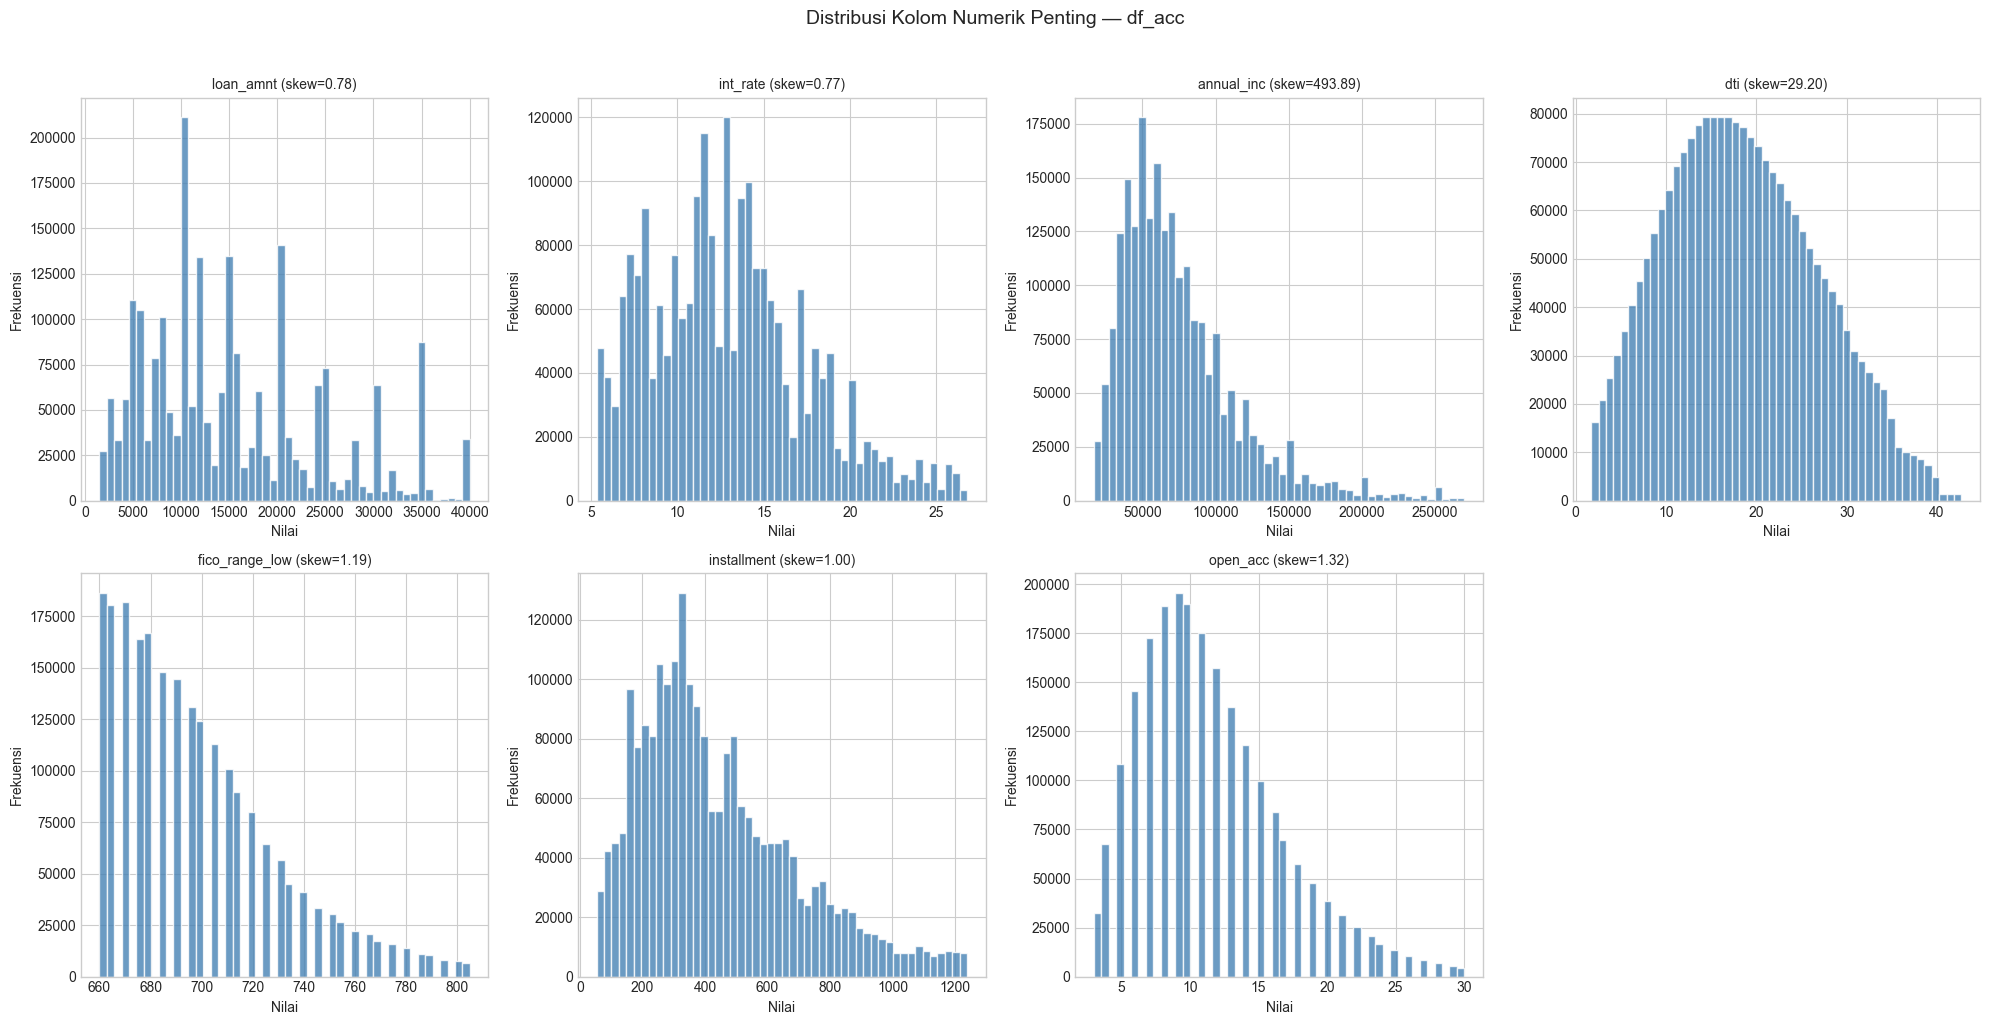

Skew > 1  : positively skewed
Skew < -1 : negatively skewed
Skew ~= 0 : mendekati normal


In [10]:
key_numeric_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                    'fico_range_low', 'installment', 'open_acc']
key_numeric_cols = [c for c in key_numeric_cols if c in df_acc.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_numeric_cols):
    data = df_acc[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    data_clipped = data[(data >= p1) & (data <= p99)]
    axes[i].hist(data_clipped, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} (skew={data.skew():.2f})', fontsize=10)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for j in range(len(key_numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Kolom Numerik Penting — df_acc', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('Results/Images/distribusi_numerik.png', dpi=120, bbox_inches='tight')
plt.show()

print('Skew > 1  : positively skewed')
print('Skew < -1 : negatively skewed')
print('Skew ~= 0 : mendekati normal')

Distribusi fitur numerik menunjukkan mayoritas variabel memiliki positive skewness.
annual_inc cenderung berdistribusi power law karena data pendapatan tidak memiliki batas
atas alami. dti menunjukkan right-skewed moderat yang bisa ditangani dengan IQR capping.

Penanganan outlier untuk kedua fitur ini berbeda:
- annual_inc tidak bisa menggunakan IQR capping. IQR capping memotong ekor kanan terlalu
  agresif sehingga ketika log transform diterapkan setelahnya, tidak ada ekor yang tersisa
  untuk dikompresi dan distribusi justru berbalik menjadi left-skewed (overcorrect).
  Oleh karena itu annual_inc ditangani dengan percentile clipping P1-P99 diikuti log1p.
- dti cukup ditangani dengan IQR capping karena setelah capping skewnessnya sudah
  mendekati simetris dan tidak membutuhkan log transform tambahan.

Distribusi Target Variable (loan_status):
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Persentase:
loan_status
Fully Paid                                             47.63%
Current                                                38.85%
Charged Off                                            11.88%
Late (31-120 days)                                      0.95%
In Grace Period                                         0.37%
Late (16-30 days) 

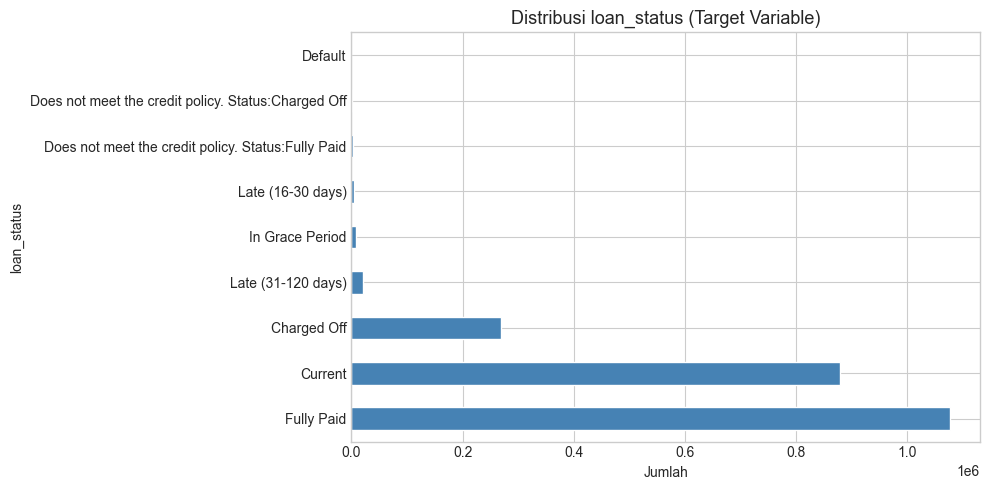

In [11]:
print('Distribusi Target Variable (loan_status):')
print(df_acc['loan_status'].value_counts())
print()
print('Persentase:')
print(df_acc['loan_status'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

fig, ax = plt.subplots(figsize=(10, 5))
df_acc['loan_status'].value_counts().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribusi loan_status (Target Variable)', fontsize=13)
ax.set_xlabel('Jumlah')
plt.tight_layout()
plt.savefig('Results/Images/loan_status_dist.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Distribusi Target Variable:

Distribusi awal menunjukkan Fully Paid sekitar 47.63% merupakan status paling dominan,
sementara Current sekitar 38.85% juga signifikan namun belum memiliki outcome final.
Charged Off sekitar 11.88% merepresentasikan pinjaman gagal bayar atau default.

Status Current, Late, dan In Grace Period dikeluarkan dari analisis karena belum mencerminkan
hasil akhir pinjaman dan dapat menyebabkan label noise dalam proses modeling.

## 1.4 — Analisis Outlier

In [12]:
def detect_outliers_iqr(df, cols):
    results = []
    for col in cols:
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outliers = ((data < lower) | (data > upper)).sum()
        results.append({
            'Kolom': col,
            'Lower Bound': lower,
            'Upper Bound': upper,
            'Jumlah Outlier': n_outliers,
            '% Outlier': round(n_outliers / len(data) * 100, 2)
        })
    return pd.DataFrame(results).sort_values('% Outlier', ascending=False)

In [13]:
numeric_cols_acc = df_acc.select_dtypes(include='number').columns.tolist()
valid_num_cols = [c for c in numeric_cols_acc if df_acc[c].dropna().shape[0] > 1000][:20]

outlier_report = detect_outliers_iqr(df_acc, valid_num_cols)
print('Laporan Outlier (IQR Method) — df_acc:')
outlier_report

Laporan Outlier (IQR Method) — df_acc:


,Kolom,Lower Bound,Upper Bound,Jumlah Outlier,% Outlier
7,delinq_2yrs,0.00,0.00,421531,18.65
14,pub_rec,0.00,0.00,357881,15.83
18,out_prncp,-9224.91,15374.85,212242,9.39
19,out_prncp_inv,-9219.47,15365.78,212305,9.39
15,revol_bal,-15494.00,41690.00,137095,6.06
5,annual_inc,-24500.00,163500.00,110041,4.87
10,inq_last_6mths,-1.50,2.50,94314,4.17
13,open_acc,-1.00,23.00,84754,3.75
8,fico_range_low,615.00,775.00,74846,3.31
9,fico_range_high,619.00,779.00,74846,3.31


Catatan untuk kolom zero-inflated seperti delinq_2yrs dan pub_rec:
IQR = 0 bukan berarti semua nilai di atas 0 adalah outlier. Kolom ini memiliki distribusi
zero-inflated di mana mayoritas bernilai 0, sehingga metode IQR tidak tepat diterapkan
dan kolom ini dikecualikan dari capping.

Terdapat juga lower bound negatif pada kolom yang secara domain tidak mungkin negatif
seperti loan_amnt dan revol_bal. Batas bawah IQR secara teoritis bisa negatif, namun
nilai negatif di kolom ini tetap di-cap ke 0 berdasarkan domain knowledge.

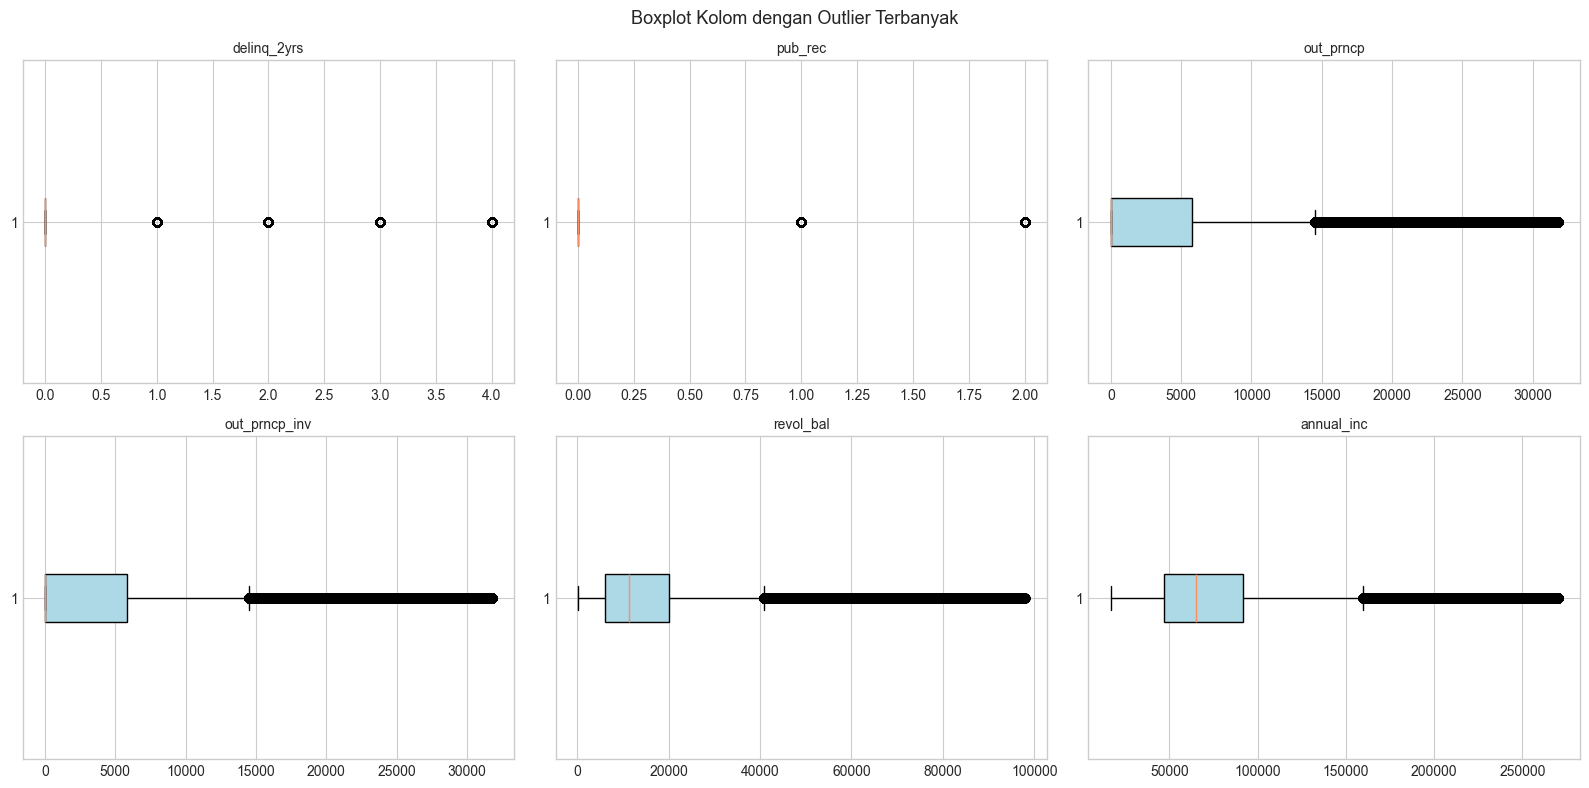

In [14]:
top_outlier_cols = outlier_report.head(6)['Kolom'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    data = df_acc[col].dropna()
    p1, p99 = data.quantile(0.01), data.quantile(0.99)
    axes[i].boxplot(
        data[(data >= p1) & (data <= p99)],
        vert=False, patch_artist=True,
        boxprops=dict(facecolor='lightblue')
    )
    axes[i].set_title(col, fontsize=10)

plt.suptitle('Boxplot Kolom dengan Outlier Terbanyak', fontsize=13)
plt.tight_layout()
plt.savefig('Results/Images/outlier_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Outlier Analysis:

Boxplot menunjukkan bahwa outlier ekstrem umumnya berada di sisi kanan (upper), konsisten
dengan distribusi right-skewed yang sudah diamati sebelumnya. annual_inc dan revol_bal
memiliki outlier paling ekstrem di antara seluruh fitur yang dianalisis.

Untuk sebagian besar fitur, outlier ditangani dengan IQR capping (winsorization): nilai
di luar batas IQR di-clip tanpa menghapus baris, sehingga tidak ada data yang hilang.

annual_inc adalah pengecualian. IQR capping tidak bisa digunakan untuk annual_inc karena
IQR upper bound memotong sekitar 5% data di sisi kanan, jauh terlalu agresif untuk
distribusi power law. Jika log transform kemudian diterapkan pada annual_inc yang sudah
di-cap, ekor kanannya sudah terlalu pendek sehingga log overcorrect dan menghasilkan
distribusi left-skewed. Oleh karena itu annual_inc akan ditangani dengan percentile
clipping P1-P99 yang hanya membuang 1% nilai paling ekstrem, diikuti log1p.

## 1.5 — Analisis Kolom Kategorik

In [15]:
cat_cols = df_acc.select_dtypes(include='object').columns.tolist()
print(f'Jumlah kolom kategorik: {len(cat_cols)}')
print()

cat_summary = pd.DataFrame({
    'Kolom': cat_cols,
    'Unique Values': [df_acc[c].nunique() for c in cat_cols],
    'Contoh Nilai': [str(df_acc[c].dropna().unique()[:3].tolist()) for c in cat_cols],
    'Missing %': [round(df_acc[c].isnull().mean() * 100, 1) for c in cat_cols]
})
cat_summary.sort_values('Unique Values').head(20)

Jumlah kolom kategorik: 38



,Kolom,Unique Values,Contoh Nilai,Missing %
26,hardship_type,1,['INTEREST ONLY-3 MONTHS DEFERRAL'],99.50
1,term,2,"[' 36 months', ' 60 months']",0.00
18,initial_list_status,2,"['w', 'f']",0.00
10,pymnt_plan,2,"['n', 'y']",0.00
22,application_type,2,"['Individual', 'Joint App']",0.00
25,hardship_flag,2,"['N', 'Y']",0.00
34,debt_settlement_flag,2,"['N', 'Y']",0.00
33,disbursement_method,2,"['Cash', 'DirectPay']",0.00
28,hardship_status,3,"['BROKEN', 'COMPLETED', 'ACTIVE']",99.50
36,settlement_status,3,"['COMPLETE', 'BROKEN', 'ACTIVE']",98.50


Pemilihan fitur kategorik dilakukan berdasarkan relevansi domain terhadap risiko kredit,
kelengkapan data, jumlah kategori yang terkelola, serta kemampuan fitur dalam memberikan
informasi terhadap target. Fitur seperti grade, term, dan purpose dipilih karena memiliki
hubungan langsung dengan profil risiko peminjam, sementara fitur dengan missing tinggi
atau variansi rendah tidak digunakan.

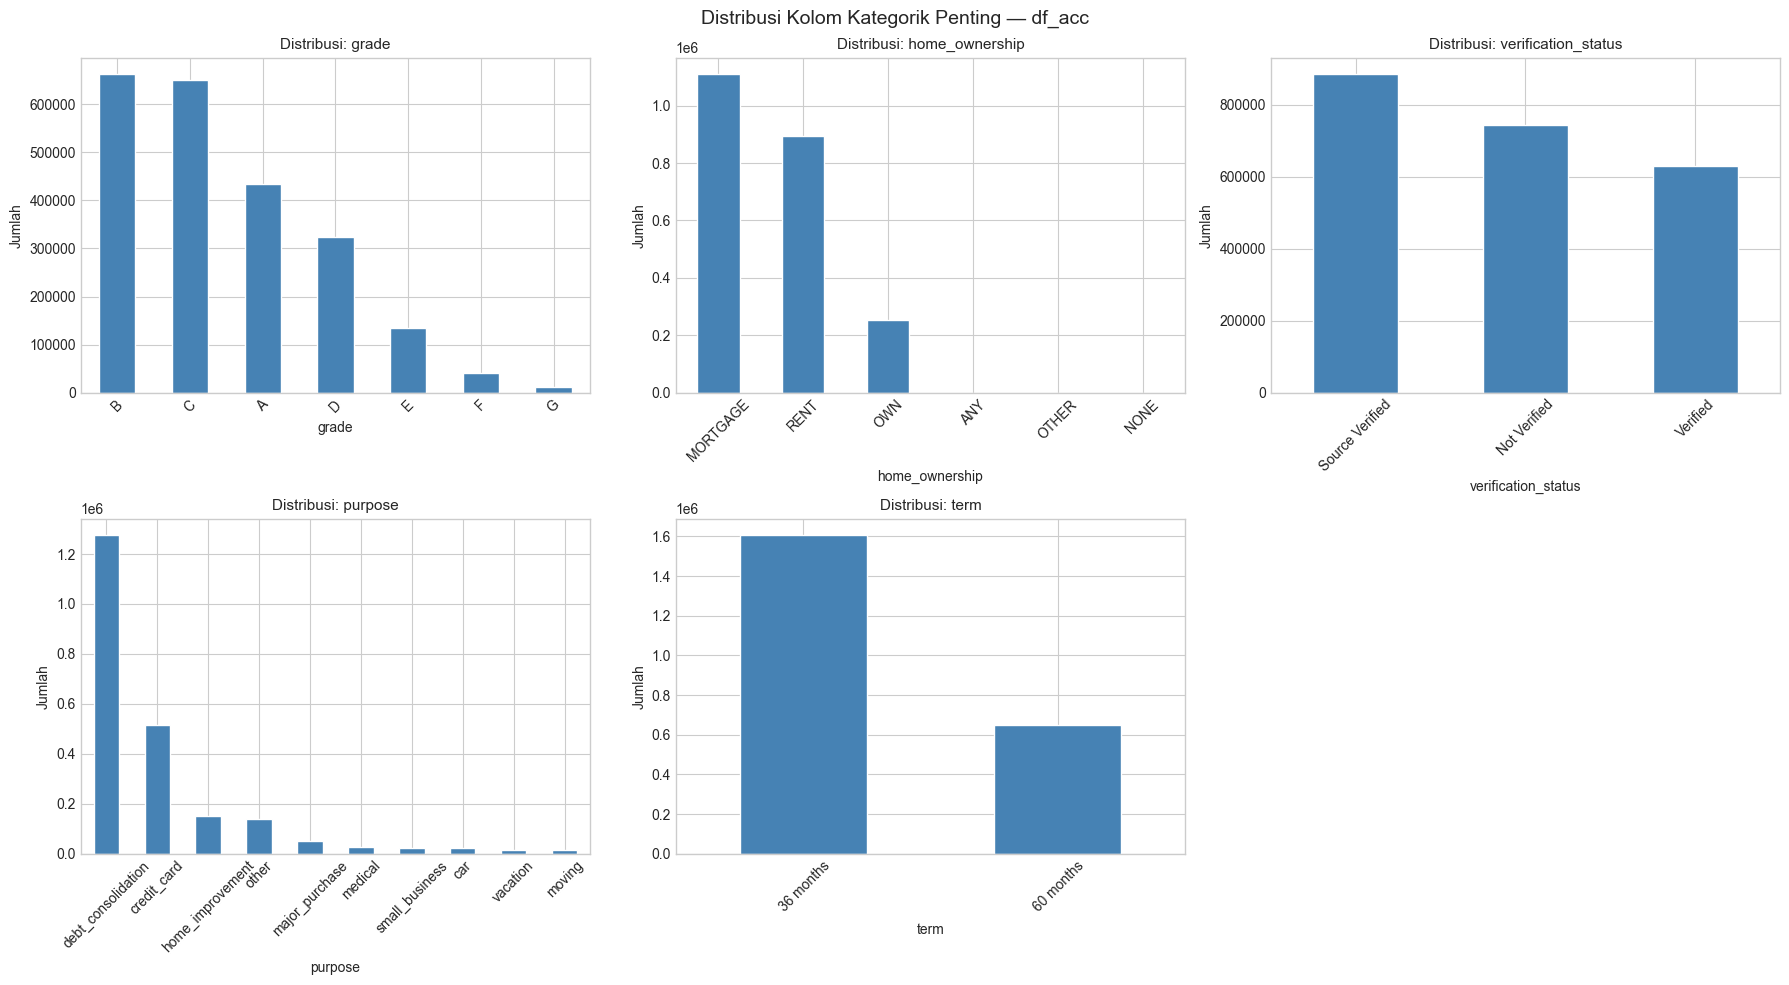

In [16]:
important_cat = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term']
important_cat = [c for c in important_cat if c in df_acc.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(important_cat):
    df_acc[col].value_counts().head(10).plot(
        kind='bar', ax=axes[i], color='steelblue', edgecolor='white'
    )
    axes[i].set_title(f'Distribusi: {col}', fontsize=11)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(important_cat), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Kolom Kategorik Penting — df_acc', fontsize=14)
plt.tight_layout()
plt.savefig('Results/Images/distribusi_kategorik.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Distribusi Fitur Kategorik:

Distribusi grade menunjukkan konsentrasi pada kategori menengah B dan C dengan penurunan
frekuensi pada grade berisiko tinggi D hingga G. Mayoritas peminjam berada pada profil
risiko menengah.

Distribusi home_ownership didominasi RENT dan MORTGAGE, menunjukkan sebagian besar peminjam
masih memiliki kewajiban perumahan yang berpotensi meningkatkan beban finansial.

Distribusi purpose menunjukkan debt_consolidation mendominasi, yang umum di platform P2P
lending karena banyak peminjam menggunakan platform untuk melunasi utang lama.

Distribusi verification_status dengan proporsi Not Verified yang tinggi menjadi fitur
prediktif penting karena peminjam yang tidak diverifikasi memiliki risiko yang lebih
sulit dinilai.

## 1.6 — EDA Khusus df_rej (Rejected Loans)

In [17]:
print('Statistik Deskriptif df_rej:')
print(df_rej.describe())
print()
print('Kolom kategorik df_rej:')
for col in df_rej.select_dtypes(include='object').columns:
    print(f'  {col}: {df_rej[col].nunique()} nilai unik — contoh: {df_rej[col].dropna().unique()[:4]}')

Statistik Deskriptif df_rej:
       Amount Requested  Risk_Score  Policy Code
count       27648741.00  9151111.00  27647823.00
mean           13133.24      628.17         0.01
std            15009.64       89.94         0.11
min                0.00        0.00         0.00
25%             4800.00      591.00         0.00
50%            10000.00      637.00         0.00
75%            20000.00      675.00         0.00
max          1400000.00      990.00         2.00

Kolom kategorik df_rej:
  Application Date: 4238 nilai unik — contoh: ['2007-05-26' '2007-05-27' '2007-05-28' '2007-05-29']
  Loan Title: 73927 nilai unik — contoh: ['Wedding Covered but No Honeymoon' 'Consolidating Debt'
 'Want to consolidate my debt' 'waksman']
  Debt-To-Income Ratio: 126145 nilai unik — contoh: ['10%' '38.64%' '9.43%' '0%']
  Zip Code: 1001 nilai unik — contoh: ['481xx' '010xx' '212xx' '017xx']
  State: 51 nilai unik — contoh: ['NM' 'MA' 'MD' 'NY']
  Employment Length: 11 nilai unik — contoh: ['4 years' 

Dataset rejected menunjukkan karakteristik distribusi yang tidak seimbang dengan outlier
ekstrem pada Amount Requested, serta beberapa fitur dengan kualitas data rendah seperti
Risk Score yang memiliki banyak missing value. Terdapat juga fitur yang perlu transformasi
tipe seperti Debt-To-Income Ratio yang tersimpan dalam format string. Fitur State dan
Employment Length tetap relevan karena mengandung informasi yang berkontribusi terhadap
profil risiko.

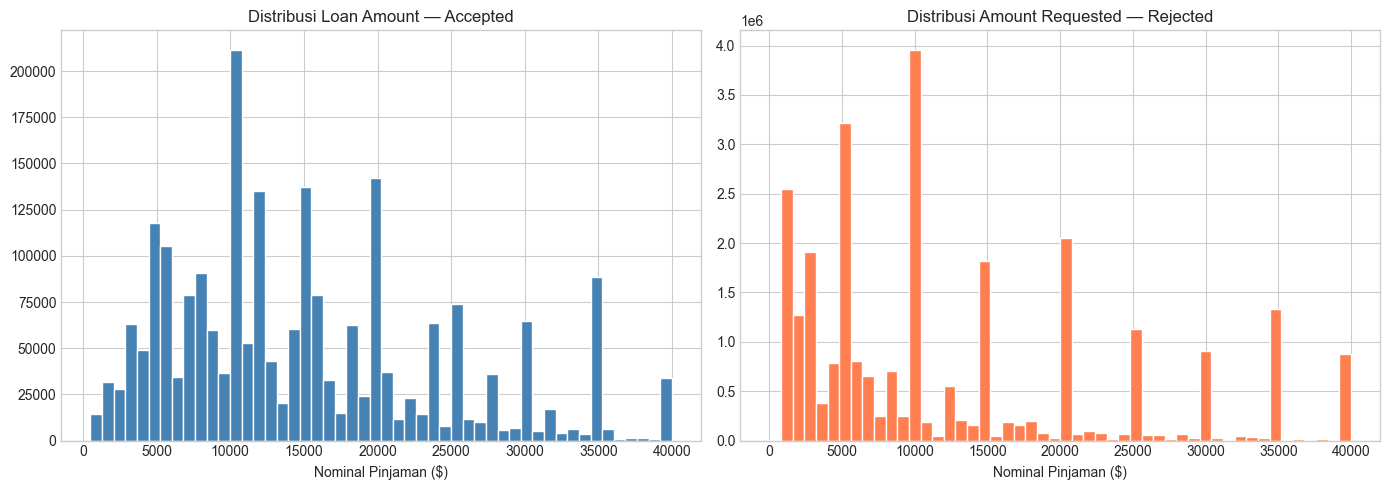

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99 = df_acc['loan_amnt'].quantile(0.99)
df_acc['loan_amnt'][df_acc['loan_amnt'] <= p99].hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribusi Loan Amount — Accepted', fontsize=12)
axes[0].set_xlabel('Nominal Pinjaman ($)')

p99r = df_rej['Amount Requested'].quantile(0.99)
df_rej['Amount Requested'][df_rej['Amount Requested'] <= p99r].hist(
    bins=50, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Distribusi Amount Requested — Rejected', fontsize=12)
axes[1].set_xlabel('Nominal Pinjaman ($)')

plt.tight_layout()
plt.savefig('Results/Images/acc_vs_rej_amount.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Distribusi Amount Accepted vs Rejected:

Distribusi loan amount pada accepted dan amount requested pada rejected sama-sama menunjukkan
pola right-skewed dengan konsentrasi pada nilai pinjaman rendah hingga menengah. Namun
terdapat perbedaan distribusi yang mengindikasikan proses seleksi dalam kebijakan kredit.

Rejected loans bukan sampel acak melainkan hasil filtering berdasarkan kriteria tertentu,
sehingga tidak merepresentasikan populasi secara keseluruhan. Penggabungan kedua dataset
untuk analisis komparatif harus mempertimbangkan selection bias ini.

---
# Langkah 2 — Data Cleaning

Prinsip: Setiap keputusan cleaning harus ada justifikasinya.

## 2.1 — Cleaning df_acc: Drop Kolom Bermasalah

In [19]:
df_acc_clean = df_acc.copy()
print(f'Shape awal: {df_acc_clean.shape}')

Shape awal: (2260701, 151)


Langkah 2: Drop kolom dengan lebih dari 50% missing value.
Kolom yang lebih dari setengah nilainya kosong tidak bisa diimputasi secara andal
tanpa mengintroduksi bias yang signifikan.

In [20]:
missing_pct = df_acc_clean.isnull().mean() * 100
cols_to_drop_missing = missing_pct[missing_pct > 50].index.tolist()

print(f'Kolom yang akan di-drop (>50% missing): {len(cols_to_drop_missing)}')
for col in cols_to_drop_missing:
    print(f'  {col}: {missing_pct[col]:.1f}% missing')

df_acc_clean.drop(columns=cols_to_drop_missing, inplace=True)
print(f'Shape setelah drop: {df_acc_clean.shape}')

Kolom yang akan di-drop (>50% missing): 44
  member_id: 100.0% missing
  desc: 94.4% missing
  mths_since_last_delinq: 51.2% missing
  mths_since_last_record: 84.1% missing
  next_pymnt_d: 59.5% missing
  mths_since_last_major_derog: 74.3% missing
  annual_inc_joint: 94.7% missing
  dti_joint: 94.7% missing
  verification_status_joint: 94.9% missing
  mths_since_recent_bc_dlq: 77.0% missing
  mths_since_recent_revol_delinq: 67.3% missing
  revol_bal_joint: 95.2% missing
  sec_app_fico_range_low: 95.2% missing
  sec_app_fico_range_high: 95.2% missing
  sec_app_earliest_cr_line: 95.2% missing
  sec_app_inq_last_6mths: 95.2% missing
  sec_app_mort_acc: 95.2% missing
  sec_app_open_acc: 95.2% missing
  sec_app_revol_util: 95.3% missing
  sec_app_open_act_il: 95.2% missing
  sec_app_num_rev_accts: 95.2% missing
  sec_app_chargeoff_within_12_mths: 95.2% missing
  sec_app_collections_12_mths_ex_med: 95.2% missing
  sec_app_mths_since_last_major_derog: 98.4% missing
  hardship_type: 99.5% miss

Langkah 3: Drop kolom ID dan non-informatif.
id adalah identifier unik pinjaman yang tidak mengandung informasi prediktif.
url adalah link halaman pinjaman yang tidak relevan untuk analisis.
emp_title, zip_code, dan title memiliki cardinality sangat tinggi sehingga tidak stabil sebagai fitur.
Catatan: member_id dan desc sudah di-drop di Langkah 2 karena memiliki missing di atas 50%.

In [21]:
cols_to_drop_manual = ['id', 'member_id', 'url', 'desc', 'emp_title', 'zip_code', 'title']
cols_to_drop_manual = [c for c in cols_to_drop_manual if c in df_acc_clean.columns]

print(f'Drop kolom non-informatif: {cols_to_drop_manual}')
df_acc_clean.drop(columns=cols_to_drop_manual, inplace=True)
print(f'Shape: {df_acc_clean.shape}')

Drop kolom non-informatif: ['id', 'url', 'emp_title', 'zip_code', 'title']
Shape: (2260701, 102)


Langkah 4: Drop kolom leaky (data leakage).
Kolom ini baru tersedia setelah pinjaman selesai. Memasukkannya ke model berarti model
mengetahui informasi masa depan yang tidak tersedia saat prediksi dibuat, sehingga
invalid secara ilmiah.

In [22]:
leaky_cols = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'out_prncp', 'out_prncp_inv', 'total_rev_hi_lim'
]
leaky_cols = [c for c in leaky_cols if c in df_acc_clean.columns]
print(f'Drop leaky columns: {leaky_cols}')

df_acc_clean.drop(columns=leaky_cols, inplace=True)
print(f'Shape: {df_acc_clean.shape}')

Drop leaky columns: ['total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'out_prncp', 'out_prncp_inv', 'total_rev_hi_lim']
Shape: (2260701, 90)


## 2.2 — Cleaning df_acc: Handle Missing Values yang Tersisa

Langkah 5: Imputasi missing value yang tersisa.
Numerik diisi dengan median karena robust terhadap outlier dan lebih representatif
untuk distribusi skewed.
Kategorik diisi dengan modus karena merepresentasikan kategori paling umum tanpa
mengubah distribusi secara signifikan.

In [23]:
remaining_missing = df_acc_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
print(f'Kolom dengan missing tersisa: {len(remaining_missing)}')

# emp_length dikecualikan dari imputasi di sini karena masih bertipe string
# ('5 years', '< 1 year', dll). Imputasi median dilakukan di cell berikutnya
# setelah emp_length dikonversi ke angka, agar nilai yang diisikan konsisten.
skip_impute = {'emp_length'}

for col in df_acc_clean.select_dtypes(include='number').columns:
    if df_acc_clean[col].isnull().any():
        df_acc_clean[col].fillna(df_acc_clean[col].median(), inplace=True)

for col in df_acc_clean.select_dtypes(include='object').columns:
    if col in skip_impute:
        continue
    if df_acc_clean[col].isnull().any():
        df_acc_clean[col].fillna(df_acc_clean[col].mode()[0], inplace=True)

print(f'Total missing setelah imputasi (kecuali emp_length): {df_acc_clean.isnull().sum().sum()}')

Kolom dengan missing tersisa: 90
Total missing setelah imputasi (kecuali emp_length): 146940


## 2.3 — Cleaning df_acc: Fix Tipe Data dan Inkonsistensi

Langkah 6: Fix kolom term.
Nilai mengandung spasi di depan seperti ' 36 months'.
Solusi: strip whitespace dan konversi ke angka.

In [24]:
if 'term' in df_acc_clean.columns:
    print('Sebelum:', df_acc_clean['term'].unique())
    df_acc_clean['term'] = (
        df_acc_clean['term']
        .str.strip()
        .str.replace(' months', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
    print('Sesudah:', df_acc_clean['term'].unique())

Sebelum: [' 36 months' ' 60 months']
Sesudah: [36 60]


Langkah 7: Fix kolom emp_length.
Nilai berupa string seperti '10+ years' dan '< 1 year'.
Dikonversi ke angka ordinal karena ada hierarki natural pada lama kerja.

In [25]:
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}

if 'emp_length' in df_acc_clean.columns:
    print('Sebelum:', df_acc_clean['emp_length'].unique())
    df_acc_clean['emp_length'] = df_acc_clean['emp_length'].map(emp_length_map)
    # Imputasi median dilakukan di sini (setelah konversi ke angka)
    # agar nilai yang diisikan konsisten dengan skala numerik 0-10
    df_acc_clean['emp_length'].fillna(df_acc_clean['emp_length'].median(), inplace=True)
    print('Sesudah:', sorted(df_acc_clean['emp_length'].unique()))

Sebelum: ['10+ years' '3 years' '4 years' '6 years' '1 year' '7 years' '8 years'
 '5 years' '2 years' '9 years' '< 1 year' nan]
Sesudah: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


Langkah 8: Fix kolom tanggal.
Kolom tanggal dalam format string seperti 'Jan-2015'.
Dikonversi ke fitur numerik year dan month agar bisa digunakan sebagai fitur model.

In [26]:
date_cols = ['issue_d', 'earliest_cr_line', 'last_credit_pull_d']
date_cols = [c for c in date_cols if c in df_acc_clean.columns]

for col in date_cols:
    try:
        df_acc_clean[col] = pd.to_datetime(df_acc_clean[col], format='%b-%Y', errors='coerce')
        df_acc_clean[f'{col}_year'] = df_acc_clean[col].dt.year
        df_acc_clean[f'{col}_month'] = df_acc_clean[col].dt.month
        df_acc_clean.drop(columns=[col], inplace=True)
        print(f'{col} -> {col}_year, {col}_month')
    except Exception as e:
        print(f'Error pada {col}: {e}')

issue_d -> issue_d_year, issue_d_month
earliest_cr_line -> earliest_cr_line_year, earliest_cr_line_month
last_credit_pull_d -> last_credit_pull_d_year, last_credit_pull_d_month


## 2.4 — Cleaning df_acc: Handle Duplikat dan Outlier

Langkah 9: Cek dan hapus duplikat.
Baris identik adalah redundansi data dan tidak menambah informasi prediktif.

In [27]:
dupes = df_acc_clean.duplicated().sum()
print(f'Jumlah duplikat: {dupes}')
if dupes > 0:
    df_acc_clean.drop_duplicates(inplace=True)
    print(f'Duplikat dihapus. Shape: {df_acc_clean.shape}')
else:
    print('Tidak ada duplikat')

Jumlah duplikat: 32
Duplikat dihapus. Shape: (2260669, 93)


Langkah 10: Handle outlier dengan IQR Capping (Winsorization).
Nilai ekstrem di-clip ke batas IQR tanpa menghapus baris, sehingga tidak ada data
yang hilang. Hanya diterapkan pada kolom numerik dengan skewness di atas 2.

annual_inc dikecualikan dari IQR capping karena IQR capping akan menghasilkan distribusi
left-skewed saat dikombinasikan dengan log transform (overcorrect). annual_inc ditangani
secara khusus dengan P1-P99 clip dan log1p di Langkah 11.

In [28]:
def cap_outliers_iqr(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
    return df

# annual_inc dikecualikan: akan ditangani P1-P99 clip + log1p di Langkah 11
skip_capping = {'annual_inc'}

skewed_threshold = 2.0
numeric_cols_now = df_acc_clean.select_dtypes(include='number').columns
skewed_cols = [
    c for c in numeric_cols_now
    if c not in skip_capping
    and abs(df_acc_clean[c].skew()) > skewed_threshold
    and df_acc_clean[c].nunique() > 10
]

print(f'Kolom skewed (|skew| > {skewed_threshold}): {len(skewed_cols)}')
print(f'Dikecualikan dari capping: {skip_capping}')
for col in skewed_cols:
    df_acc_clean = cap_outliers_iqr(df_acc_clean, col)
    print(f'  capping: {col}')

# Domain correction dti: IQR lower bound bisa negatif secara matematis,
# padahal dti adalah rasio yang tidak bisa bernilai negatif secara domain.
if 'dti' in df_acc_clean.columns:
    n_neg = (df_acc_clean['dti'] < 0).sum()
    n_inf = np.isinf(df_acc_clean['dti']).sum()
    if n_neg > 0 or n_inf > 0:
        print(f'  domain correction dti: {n_neg} negatif, {n_inf} inf -> clip ke 0')
    df_acc_clean['dti'] = df_acc_clean['dti'].replace([np.inf, -np.inf], np.nan)
    df_acc_clean['dti'] = df_acc_clean['dti'].clip(lower=0)
    df_acc_clean['dti'].fillna(df_acc_clean['dti'].median(), inplace=True)

print(f'Shape setelah capping: {df_acc_clean.shape}')
print(f'dti range: [{df_acc_clean["dti"].min():.2f}, {df_acc_clean["dti"].max():.2f}]')
print(f'annual_inc skewness saat ini: {df_acc_clean["annual_inc"].skew():.4f} (belum ditransform)')

Kolom skewed (|skew| > 2.0): 39
Dikecualikan dari capping: {'annual_inc'}
  capping: dti
  capping: delinq_2yrs
  capping: inq_last_6mths
  capping: pub_rec
  capping: revol_bal
  capping: last_fico_range_low
  capping: collections_12_mths_ex_med
  capping: tot_coll_amt
  capping: tot_cur_bal
  capping: open_acc_6m
  capping: open_act_il
  capping: open_il_12m
  capping: open_il_24m
  capping: mths_since_rcnt_il
  capping: total_bal_il
  capping: open_rv_12m
  capping: open_rv_24m
  capping: max_bal_bc
  capping: inq_fi
  capping: total_cu_tl
  capping: inq_last_12m
  capping: avg_cur_bal
  capping: bc_open_to_buy
  capping: chargeoff_within_12_mths
  capping: delinq_amnt
  capping: mo_sin_rcnt_rev_tl_op
  capping: mo_sin_rcnt_tl
  capping: mths_since_recent_bc
  capping: num_accts_ever_120_pd
  capping: num_il_tl
  capping: num_tl_90g_dpd_24m
  capping: pct_tl_nvr_dlq
  capping: pub_rec_bankruptcies
  capping: tax_liens
  capping: tot_hi_cred_lim
  capping: total_bal_ex_mort
  capping

Langkah 11: Transformasi annual_inc dengan P1-P99 Clip dan Log Transform.

annual_inc tidak bisa menggunakan IQR capping karena distribusinya mengikuti power law
dengan outlier ekstrem yang sangat jauh di atas median (skewness mencapai ratusan).
IQR capping memotong ekor kanan terlalu agresif — ketika log transform diterapkan
setelahnya, distribusi justru berbalik menjadi left-skewed (overcorrect) karena tidak ada
ekor kanan yang tersisa untuk dikompresi oleh log.

Solusi yang digunakan adalah dua tahap:
1. Percentile clipping P1-P99: hanya membuang 1% nilai paling ekstrem di setiap sisi.
   Ini jauh lebih konservatif dari IQR capping dan membiarkan distribusi power law
   alami annual_inc tetap utuh untuk diproses log.
2. Log transform (np.log1p): mengompresi distribusi power law mendekati normal.

dti tidak perlu log transform karena setelah IQR capping skewnessnya sudah 0.35
yang hampir simetris. StandardScaler sudah cukup untuk menstandarisasi dti.

Berikut konfirmasi skewness annual_inc dan rentang P1-P99 sebelum transformasi diterapkan,
untuk memverifikasi bahwa outlier ekstrem memang ada dan perlu ditangani.

In [29]:
# Cek skewness sebelum dan sesudah percentile clipping untuk annual_inc
if 'annual_inc' in df_acc_clean.columns:
    skew_before = df_acc_clean['annual_inc'].skew()
    p99_val = df_acc_clean['annual_inc'].quantile(0.99)
    p1_val  = df_acc_clean['annual_inc'].quantile(0.01)
    print(f'annual_inc sebelum P99 clip : skew = {skew_before:.4f}')
    print(f'  P1  = {p1_val:,.0f}')
    print(f'  P99 = {p99_val:,.0f}')
    print(f'  Nilai di atas P99 yang akan di-clip: {(df_acc_clean["annual_inc"] > p99_val).sum():,} baris ({(df_acc_clean["annual_inc"] > p99_val).mean()*100:.2f}%)')

cols_to_check = ['dti']
print()
print('Skewness dti setelah IQR capping:')
for col in cols_to_check:
    if col in df_acc_clean.columns:
        skew_val = df_acc_clean[col].skew()
        status = 'perlu log transform' if abs(skew_val) > 0.5 else 'sudah cukup simetris, tidak perlu log transform'
        print(f'  {col:<15}: skew = {skew_val:>7.4f}  ->  {status}')

annual_inc sebelum P99 clip : skew = 493.8866
  P1  = 16,800
  P99 = 270,000
  Nilai di atas P99 yang akan di-clip: 22,543 baris (1.00%)

Skewness dti setelah IQR capping:
  dti            : skew =  0.3462  ->  sudah cukup simetris, tidak perlu log transform


Setelah dikonfirmasi bahwa skewness annual_inc sangat tinggi dan rentang P99 masih
representatif, berikut penerapan dua tahap transformasi: P1-P99 clip diikuti log1p.

annual_inc clipped ke [16,800, 270,000]
Skewness setelah P99 clip : 1.7928

Skewness sesudah log transform:
  annual_inc: 0.0637


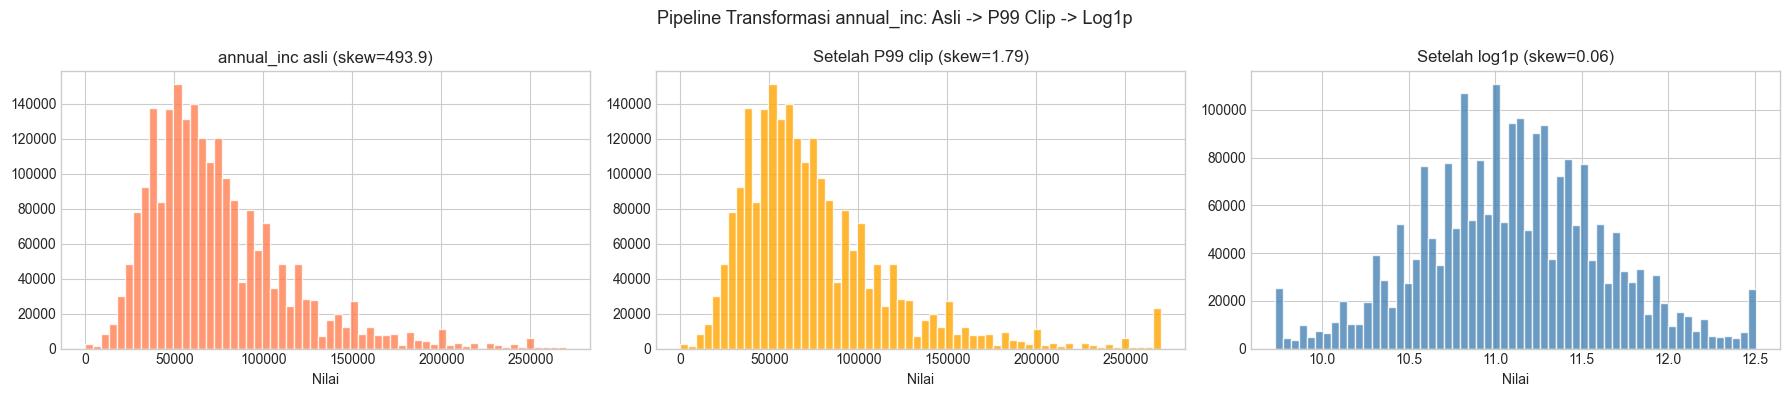

Transformasi annual_inc selesai


In [30]:
# Simpan nilai annual_inc sebelum log transform untuk keperluan binning di Langkah 3.4
# Binning harus menggunakan nilai asli agar batas bin (30K, 60K, dst) bermakna secara bisnis
annual_inc_before_log = df_acc_clean['annual_inc'].copy()

# Tahap 1: Percentile clipping P1-P99 untuk annual_inc
if 'annual_inc' in df_acc_clean.columns:
    p1_val  = df_acc_clean['annual_inc'].quantile(0.01)
    p99_val = df_acc_clean['annual_inc'].quantile(0.99)
    df_acc_clean['annual_inc'] = df_acc_clean['annual_inc'].clip(lower=p1_val, upper=p99_val)
    print(f'annual_inc clipped ke [{p1_val:,.0f}, {p99_val:,.0f}]')
    print(f'Skewness setelah P99 clip : {df_acc_clean["annual_inc"].skew():.4f}')

# Simpan skew setelah clipping (SEBELUM log)
skew_clipped = df_acc_clean['annual_inc'].skew()

# Tahap 2: Log transform
log_transform_cols = [c for c in ['annual_inc'] if c in df_acc_clean.columns]

for col in log_transform_cols:
    df_acc_clean[col] = np.log1p(df_acc_clean[col])

print()
print('Skewness sesudah log transform:')
for col in log_transform_cols:
    print(f'  {col}: {df_acc_clean[col].skew():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: distribusi asli (clip P99 untuk tampilan)
raw_data = df_acc['annual_inc'].replace([np.inf, -np.inf], np.nan).dropna()
p99_raw = raw_data.quantile(0.99)
raw_data[raw_data <= p99_raw].hist(bins=60, ax=axes[0], color='coral', edgecolor='white', alpha=0.8)
axes[0].set_title(f'annual_inc asli (skew={raw_data.skew():.1f})')
axes[0].set_xlabel('Nilai')

# Panel 2: setelah P99 clip (sebelum log)
clipped_ref = raw_data.clip(upper=p99_raw)
clipped_ref.hist(bins=60, ax=axes[1], color='orange', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Setelah P99 clip (skew={skew_clipped:.2f})')
axes[1].set_xlabel('Nilai')

# Panel 3: setelah log transform
df_acc_clean['annual_inc'].hist(bins=60, ax=axes[2], color='steelblue', edgecolor='white', alpha=0.8)
axes[2].set_title(f'Setelah log1p (skew={df_acc_clean["annual_inc"].skew():.2f})')
axes[2].set_xlabel('Nilai')

plt.suptitle('Pipeline Transformasi annual_inc: Asli -> P99 Clip -> Log1p', fontsize=13)
plt.tight_layout()
plt.savefig('Results/Images/log_transform_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Transformasi annual_inc selesai')

Insight Log Transform:

annual_inc memiliki outlier ekstrem yang menyebabkan skewness mencapai 493 pada data
setelah cleaning. Tanpa penanganan outlier, log1p akan overcorrect dan menghasilkan
distribusi left-skewed karena log tidak bisa mengompresi nilai yang ratusan kali lebih
besar dari median secara proporsional.

Dengan pipeline P1-P99 clip lalu log1p, skewness turun dari 493 ke 1.79 setelah clip,
lalu ke 0.06 setelah log1p. Skewness 0.06 sangat mendekati distribusi simetris
dan merupakan hasil yang baik untuk fitur ini.

dti tidak ditransformasi karena skewnessnya sudah ~0.35 setelah IQR capping,
yang tergolong hampir simetris. StandardScaler sudah cukup untuk menstandarisasi dti.

## 2.5 — Cleaning df_rej: Pipeline Terpisah

In [31]:
df_rej_clean = df_rej.copy()
print(f'Shape awal: {df_rej_clean.shape}')


Shape awal: (27648741, 9)


Langkah 1 df_rej: Hapus duplikat.
Baris identik adalah redundansi data dan tidak menambah informasi.

In [32]:
n_dupes = df_rej_clean.duplicated().sum()
print(f'Jumlah duplikat: {n_dupes:,}')
df_rej_clean.drop_duplicates(inplace=True)
print(f'Shape setelah drop duplikat: {df_rej_clean.shape}')

Jumlah duplikat: 157,954
Shape setelah drop duplikat: (27490787, 9)


Langkah 2 df_rej: Fix kolom Debt-To-Income Ratio.
Nilai berformat string seperti '10%' dan '38.64%' harus dikonversi ke float
agar bisa digunakan untuk analisis numerik.

In [33]:
if 'Debt-To-Income Ratio' in df_rej_clean.columns:
    print('Sebelum:', df_rej_clean['Debt-To-Income Ratio'].dtype)
    df_rej_clean['Debt-To-Income Ratio'] = (
        df_rej_clean['Debt-To-Income Ratio']
        .str.replace('%', '', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
    print('Sesudah:', df_rej_clean['Debt-To-Income Ratio'].dtype)
    print(df_rej_clean['Debt-To-Income Ratio'].describe())

Sebelum: object
Sesudah: float64
count   27490787.00
mean         143.41
std        10566.67
min           -1.00
25%            8.10
50%           19.98
75%           36.53
max     50000031.49
Name: Debt-To-Income Ratio, dtype: float64


Langkah 3 df_rej: Handle missing values.
Risk_Score memiliki missing 66.9% sehingga di-drop karena tidak bisa diimputasi secara andal.
Kolom lain diimputasi dengan median untuk numerik dan modus untuk kategorik.

In [34]:
print('Missing sebelum:')
print(df_rej_clean.isnull().sum())

missing_rej_pct = df_rej_clean.isnull().mean() * 100
cols_drop_rej = missing_rej_pct[missing_rej_pct > 50].index.tolist()
print(f'\nDrop kolom (>50% missing): {cols_drop_rej}')
df_rej_clean.drop(columns=cols_drop_rej, inplace=True)

for col in df_rej_clean.select_dtypes(include='object').columns:
    if df_rej_clean[col].isnull().any():
        df_rej_clean[col].fillna(df_rej_clean[col].mode()[0], inplace=True)

for col in df_rej_clean.select_dtypes(include='number').columns:
    if df_rej_clean[col].isnull().any():
        df_rej_clean[col].fillna(df_rej_clean[col].median(), inplace=True)

print(f'Missing setelah cleaning: {df_rej_clean.isnull().sum().sum()}')
print(f'Shape final df_rej_clean: {df_rej_clean.shape}')

Missing sebelum:
Amount Requested               0
Application Date               0
Loan Title                  1285
Risk_Score              18359858
Debt-To-Income Ratio           0
Zip Code                     292
State                         22
Employment Length         949702
Policy Code                  918
dtype: int64

Drop kolom (>50% missing): ['Risk_Score']
Missing setelah cleaning: 0
Shape final df_rej_clean: (27490787, 8)


Langkah 4 df_rej: Fix kolom Employment Length.
Nilai berupa string seperti '10+ years' dikonversi ke angka ordinal untuk konsistensi
dengan emp_length di df_acc.

In [35]:
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}

if 'Employment Length' in df_rej_clean.columns:
    df_rej_clean['Employment Length'] = df_rej_clean['Employment Length'].map(emp_map)
    df_rej_clean['Employment Length'].fillna(df_rej_clean['Employment Length'].median(), inplace=True)
    print('Employment Length berhasil dikonversi ke angka')

Employment Length berhasil dikonversi ke angka


---
# Langkah 3 — Data Transformation

Tujuan: Ubah bentuk data agar algoritma machine learning bisa memproses dengan optimal.

## 3.1 — Encoding Target Variable (loan_status)

Langkah 1: Encoding target variable loan_status ke binary.
Fokus pada klasifikasi binary Fully Paid vs Default & Charged Off. Status lain seperti Current dan Late
belum memiliki outcome final sehingga dibuang agar tidak menambah noise pada model.

In [36]:
print('Nilai unik loan_status:', df_acc_clean['loan_status'].unique())
print('\nDistribusi:')
print(df_acc_clean['loan_status'].value_counts())

status_map = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1,
}

df_acc_clean['loan_status_binary'] = df_acc_clean['loan_status'].map(status_map)

before = len(df_acc_clean)
df_acc_clean.dropna(subset=['loan_status_binary'], inplace=True)
after = len(df_acc_clean)

print(f'\nBaris dihapus (loan masih berjalan): {before - after:,}')
print('\nDistribusi target binary:')
print(df_acc_clean['loan_status_binary'].value_counts())
print('0 = Fully Paid, 1 = Default/Charged Off')

Nilai unik loan_status: ['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']

Distribusi:
loan_status
Fully Paid                                             1076752
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Baris dihapus (loan masih berjalan): 912,569

Distribusi target binary:
loan_status_binary
0.00    1078740
1.00     269360
Name: count, dty

## 3.1b — Class Imbalance Analysis

In [37]:
y_temp = df_acc_clean['loan_status_binary'].dropna().astype(int)

print('Class Imbalance Analysis:')
print(f'  Fully Paid (0): {(y_temp==0).sum():,} ({(y_temp==0).mean()*100:.1f}%)')
print(f'  Default    (1): {(y_temp==1).sum():,} ({(y_temp==1).mean()*100:.1f}%)')
print(f'  Rasio      : {(y_temp==0).sum()/(y_temp==1).sum():.1f} : 1')

Class Imbalance Analysis:
  Fully Paid (0): 1,078,740 (80.0%)
  Default    (1): 269,360 (20.0%)
  Rasio      : 4.0 : 1


Langkah 2: Visualisasi class imbalance dan dokumentasi implikasinya.

Insight Class Imbalance:

Dataset ini memiliki distribusi kelas 80% Fully Paid dan 20% Default dengan rasio 4:1.
Ini merupakan imbalance yang moderat dan berdampak langsung pada konfigurasi algoritma
yang akan digunakan selanjutnya.

Untuk Apriori, min_support harus di-set rendah minimal 0.05 agar pola kelas minoritas
Default tetap terdeteksi. Untuk K-Means dan DBSCAN, klaster yang terbentuk kemungkinan
didominasi pola Fully Paid sehingga diperlukan post-hoc analysis per klaster untuk
melihat komposisi Default.

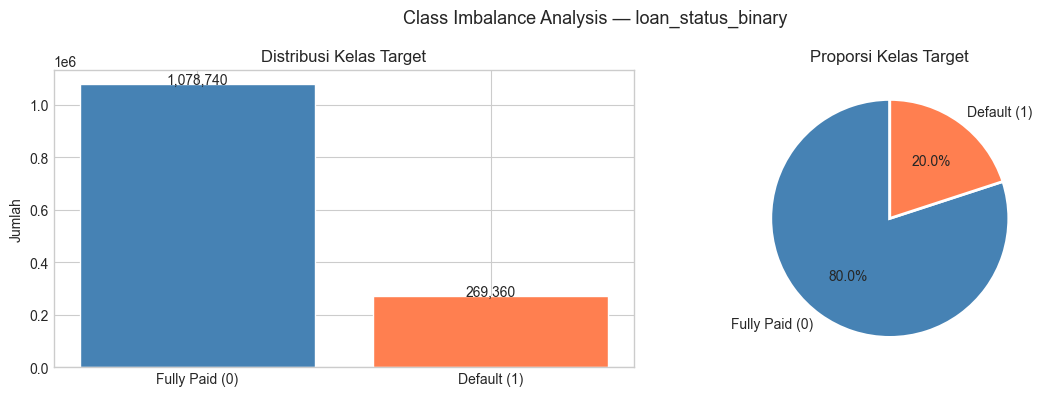

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels_ci = ['Fully Paid (0)', 'Default (1)']
values_ci = [(y_temp==0).sum(), (y_temp==1).sum()]
colors_ci = ['steelblue', 'coral']

axes[0].bar(labels_ci, values_ci, color=colors_ci, edgecolor='white')
axes[0].set_title('Distribusi Kelas Target', fontsize=12)
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(values_ci):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center')

axes[1].pie(values_ci, labels=labels_ci, colors=colors_ci,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kelas Target', fontsize=12)

plt.suptitle('Class Imbalance Analysis — loan_status_binary', fontsize=13)
plt.tight_layout()
plt.savefig('Results/Images/class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()

## 3.2 — Encoding Fitur Kategorik

Langkah 3: Ordinal Encoding untuk kolom dengan urutan natural.
Grade (A sampai G) memiliki hierarki yang bermakna secara bisnis sehingga label encoding
lebih tepat daripada one-hot encoding.

In [39]:
# Simpan nilai asli grade & sub_grade sebelum encoding
# Versi string ini akan digunakan di Langkah persiapan Apriori
# (OHE pada string menghasilkan grade_A, grade_B, ... yang bermakna)
grade_before_encode    = df_acc_clean['grade'].copy()    if 'grade'     in df_acc_clean.columns else None
sub_grade_before_encode = df_acc_clean['sub_grade'].copy() if 'sub_grade' in df_acc_clean.columns else None

# Ordinal encoding untuk modeling (K-Means, DBSCAN, dll)
if 'grade' in df_acc_clean.columns:
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df_acc_clean['grade'] = df_acc_clean['grade'].map(grade_map)
    print('grade encoded:', sorted(df_acc_clean['grade'].unique()))

if 'sub_grade' in df_acc_clean.columns:
    le = LabelEncoder()
    df_acc_clean['sub_grade'] = le.fit_transform(df_acc_clean['sub_grade'].astype(str))
    print(f'sub_grade encoded: {df_acc_clean["sub_grade"].nunique()} nilai unik')

grade encoded: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
sub_grade encoded: 35 nilai unik


Langkah 4: One-Hot Encoding untuk kolom nominal tanpa urutan natural.
drop_first=True untuk menghindari dummy variable trap yang menyebabkan multikolinearitas.

In [40]:
ohe_cols = ['home_ownership', 'verification_status', 'purpose',
            'disbursement_method', 'initial_list_status']
ohe_cols = [c for c in ohe_cols if c in df_acc_clean.columns]

shape_before = df_acc_clean.shape
df_acc_clean = pd.get_dummies(df_acc_clean, columns=ohe_cols, drop_first=True, dtype=int)

print(f'Kolom di-OHE: {ohe_cols}')
print(f'Shape sebelum OHE: {shape_before}')
print(f'Shape sesudah OHE : {df_acc_clean.shape}')
print(f'Kolom baru: {df_acc_clean.shape[1] - shape_before[1]}')

Kolom di-OHE: ['home_ownership', 'verification_status', 'purpose', 'disbursement_method', 'initial_list_status']
Shape sebelum OHE: (1348100, 94)
Shape sesudah OHE : (1348100, 111)
Kolom baru: 17


## 3.3 — Normalisasi (Scaling)

Langkah 5: Normalisasi dengan StandardScaler.
annual_inc sudah lebih mendekati normal setelah log transform.
dti sudah mendekati normal setelah IQR capping maka tidak perlu log transform.
StandardScaler dipilih karena menghasilkan mean=0 dan std=1 yang optimal untuk algoritma
berbasis jarak seperti K-Means dan DBSCAN, serta lebih robust terhadap sisa outlier
dibanding MinMaxScaler. Kolom biner hasil OHE dan target dikecualikan karena sudah
dalam range yang sesuai.

In [41]:
target_col = 'loan_status_binary'
cols_to_exclude = [target_col, 'loan_status']

# Simpan hasil log (sebelum scaling) untuk visualisasi
log_temp = df_acc_clean['annual_inc'].copy()

numeric_for_scale = [
    c for c in df_acc_clean.select_dtypes(include='number').columns
    if c not in cols_to_exclude and df_acc_clean[c].nunique() > 2
]

# ── Simpan snapshot kolom numerik SEBELUM scaling untuk binning Langkah 3.4 ──
# annual_inc sudah disimpan sebelumnya sebagai annual_inc_before_log
# Kolom lain masih dalam satuan asli (dolar, %, rasio) sehingga batas bin bermakna
cols_to_snapshot = ['loan_amnt', 'int_rate', 'dti', 'installment',
                    'last_fico_range_low', 'fico_range_low']
snapshot_before_scale = {
    col: df_acc_clean[col].copy()
    for col in cols_to_snapshot
    if col in df_acc_clean.columns
}
print(f'Snapshot sebelum scaling disimpan untuk: {list(snapshot_before_scale.keys())}')

print(f'Jumlah kolom yang akan di-scale: {len(numeric_for_scale)}')

scaler = StandardScaler()
df_acc_clean[numeric_for_scale] = scaler.fit_transform(df_acc_clean[numeric_for_scale])
print('StandardScaler diterapkan')
print(f'Shape: {df_acc_clean.shape}')

Snapshot sebelum scaling disimpan untuk: ['loan_amnt', 'int_rate', 'dti', 'installment', 'last_fico_range_low', 'fico_range_low']
Jumlah kolom yang akan di-scale: 68
StandardScaler diterapkan
Shape: (1348100, 111)


Visualisasi perbandingan annual_inc.
Panel kiri menunjukkan distribusi setelah P99 clip, dan log1p (sebelum scaling).
Panel kanan menunjukkan distribusi setelah StandardScaler.

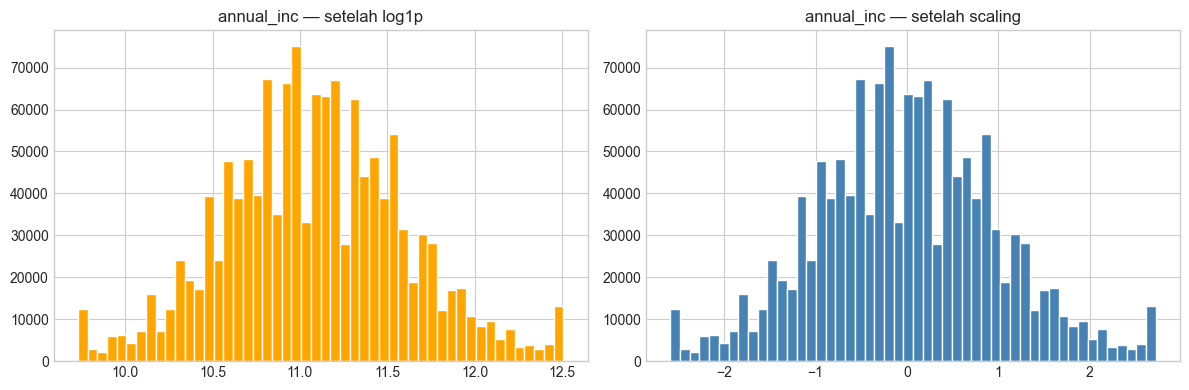

In [42]:
sample_col = 'annual_inc' if 'annual_inc' in numeric_for_scale else numeric_for_scale[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ======================
# KIRI: setelah log1p
# ======================
axes[0].hist(log_temp, bins=50, color='orange', edgecolor='white')
axes[0].set_title(f'{sample_col} — setelah log1p')

# ======================
# KANAN: setelah scaling
# ======================
scaled_data = df_acc_clean[sample_col]
axes[1].hist(scaled_data, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title(f'{sample_col} — setelah scaling')

plt.tight_layout()
plt.savefig('Results/Images/normalisasi_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Normalisasi:

Setelah StandardScaler, semua fitur numerik kontinu berada pada skala mean=0 dan std=1.
annual_inc yang sudah di-log transform akan semakin terstandardisasi dengan baik.
dti yang sudah simetris setelah IQR capping juga distandarisasi tanpa perlu transformasi tambahan.

StandardScaler optimal untuk algoritma berbasis jarak seperti K-Means dan DBSCAN karena
keduanya sangat sensitif terhadap perbedaan skala — fitur dengan rentang besar akan
mendominasi perhitungan jarak jika tidak di-scale. Kolom biner hasil OHE tidak perlu
di-scale karena sudah berada dalam range 0-1 secara alami.

## 3.4 — Binning (Diskretisasi Variabel Kontinu)

Binning menggunakan **snapshot nilai sebelum StandardScaler** (`snapshot_before_scale`)
yang disimpan di Langkah 3.3. Dengan cara ini:
- Data sudah bersih (tidak ada missing, outlier sudah di-cap dari Langkah 2)
- Nilai masih dalam satuan asli (dolar, persen, rasio) → batas bin bermakna
- Khusus `annual_inc` menggunakan `annual_inc_before_log` (sebelum log transform)

Empat fitur yang di-bin:
- loan_amnt  : ukuran pinjaman (Micro, Small, Medium, Large, Very Large)
- annual_inc : kelompok pendapatan (Low hingga Very High) — nilai pre-log
- int_rate   : rentang suku bunga sebagai proksi risiko kredit
- dti        : kategori risiko keuangan mengikuti standar industri lending

Binning loan_amnt

In [43]:
# df_binned dibuat dari df_acc_clean (sudah cleaned & scaled)
# Namun untuk binning, nilai numerik diganti dari snapshot_before_scale
# agar batas bin bermakna dalam satuan asli (dolar, %, rasio)
df_binned = df_acc_clean.copy()

if 'loan_amnt' in snapshot_before_scale:
    df_binned['loan_amnt_bin'] = pd.cut(
        snapshot_before_scale['loan_amnt'],
        bins=[0, 5000, 10000, 20000, 35000, float('inf')],
        labels=['Micro (<5K)', 'Small (5-10K)', 'Medium (10-20K)', 'Large (20-35K)', 'Very Large (>35K)']
    )
    print('loan_amnt_bin:')
    print(df_binned['loan_amnt_bin'].value_counts())

loan_amnt_bin:
loan_amnt_bin
Medium (10-20K)      498579
Small (5-10K)        374487
Large (20-35K)       282792
Micro (<5K)          182982
Very Large (>35K)      9260
Name: count, dtype: int64


Binning annual_inc

In [44]:
# annual_inc menggunakan annual_inc_before_log (sebelum P1-P99 clip + log transform)
# agar batas bin [0, 30K, 60K, ...] bermakna dalam satuan dolar asli
if annual_inc_before_log is not None:
    df_binned['income_bin'] = pd.cut(
        annual_inc_before_log,
        bins=[0, 30000, 60000, 100000, 200000, float('inf')],
        labels=['Low (<30K)', 'Lower-Mid (30-60K)', 'Mid (60-100K)', 'High (100-200K)', 'Very High (>200K)']
    )
    print('income_bin:')
    print(df_binned['income_bin'].value_counts())

income_bin:
income_bin
Lower-Mid (30-60K)    519686
Mid (60-100K)         478174
High (100-200K)       222428
Low (<30K)             99407
Very High (>200K)      28044
Name: count, dtype: int64


Binning dti mengikuti standar industri keuangan:
Very Low (< 10): kewajiban utang sangat kecil relatif terhadap pendapatan.
Low (10-20): terkelola baik, masih dalam batas aman.
Medium (20-30): mulai perlu perhatian.
High (30-40): berisiko menurut standar lending.
Very High (> 40): risiko tinggi gagal bayar.

Proporsi kategori High dan Very High relevan sebagai pertimbangan minimum support
threshold saat menjalankan Apriori.

In [45]:
# dti menggunakan snapshot_before_scale agar batas bin [0, 10, 20, ...]
# bermakna dalam satuan rasio asli (bukan z-score)
if 'dti' in snapshot_before_scale:
    df_binned['dti_bin'] = pd.cut(
        snapshot_before_scale['dti'],
        bins=[0, 10, 20, 30, 40, float('inf')],
        labels=['Very Low (<10)', 'Low (10-20)', 'Medium (20-30)', 'High (30-40)', 'Very High (>40)']
    )
    print('dti_bin:')
    print(df_binned['dti_bin'].value_counts())

dti_bin:
dti_bin
Low (10-20)        563723
Medium (20-30)     409035
Very Low (<10)     246152
High (30-40)       121541
Very High (>40)      6766
Name: count, dtype: int64


Binning int_rate (suku bunga)

In [46]:
# int_rate menggunakan snapshot_before_scale agar batas bin [0, 8, 12, ...]
# bermakna dalam satuan persen asli (bukan z-score)
if 'int_rate' in snapshot_before_scale:
    df_binned['int_rate_bin'] = pd.cut(
        snapshot_before_scale['int_rate'],
        bins=[0, 8, 12, 16, 20, float('inf')],
        labels=['Very Low (<8%)', 'Low (8-12%)', 'Medium (12-16%)', 'High (16-20%)', 'Very High (>20%)']
    )
    print('int_rate_bin:')
    print(df_binned['int_rate_bin'].value_counts())

int_rate_bin:
int_rate_bin
Medium (12-16%)     421352
Low (8-12%)         382853
High (16-20%)       228223
Very Low (<8%)      208480
Very High (>20%)    107192
Name: count, dtype: int64


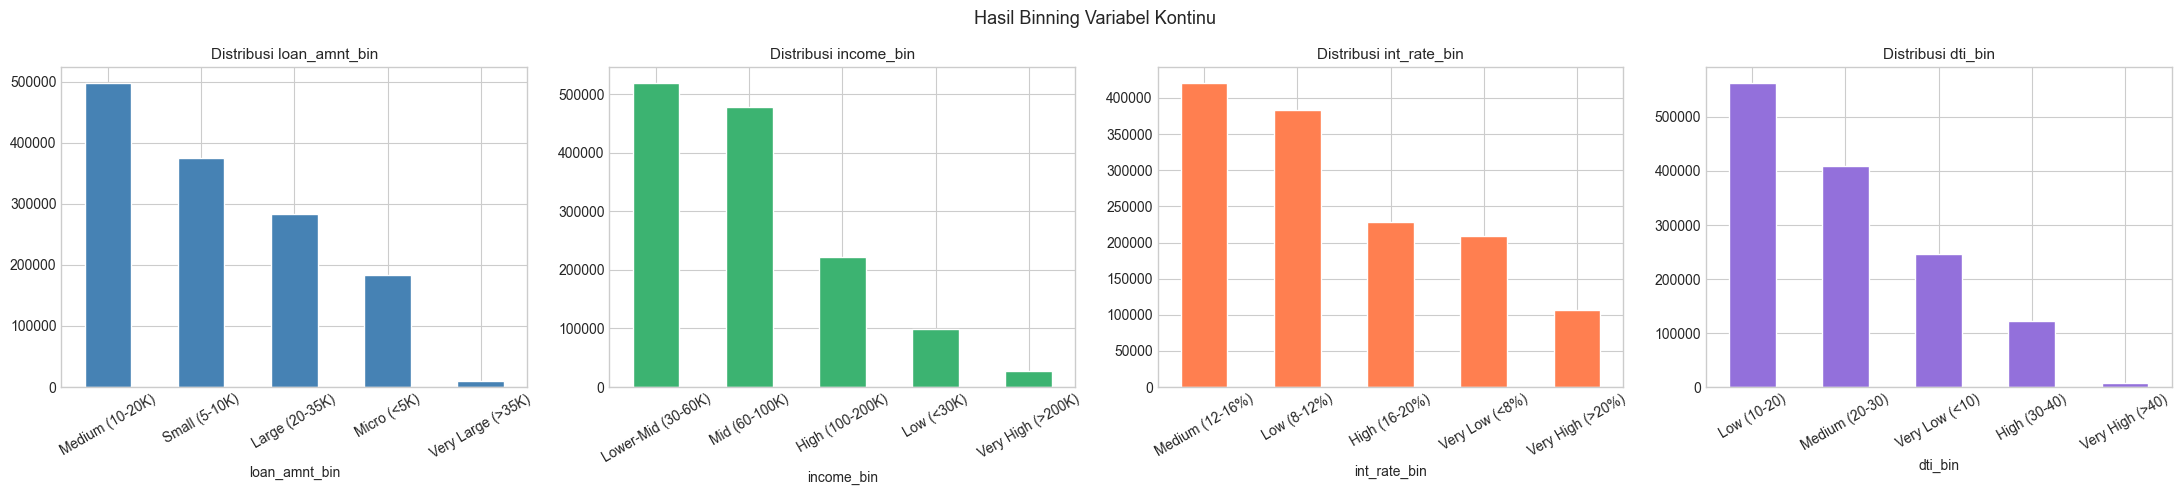

In [47]:
bin_cols = ['loan_amnt_bin', 'income_bin', 'int_rate_bin', 'dti_bin']
bin_cols = [c for c in bin_cols if c in df_binned.columns]

fig, axes = plt.subplots(1, len(bin_cols), figsize=(22, 5))
colors = ['steelblue', 'mediumseagreen', 'coral', 'mediumpurple']

for i, col in enumerate(bin_cols):
    df_binned[col].value_counts().plot(kind='bar', ax=axes[i], color=colors[i], edgecolor='white')
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Hasil Binning Variabel Kontinu', fontsize=13)
plt.tight_layout()
plt.savefig('Results/Images/binning_result.png', dpi=120, bbox_inches='tight')
plt.show()

In [48]:
# df_acc_clean_for_apriori adalah df_acc_clean (sudah scaled) + kolom bin hasil Langkah 3.4
# Kolom numerik di dalamnya sudah dalam bentuk z-score (StandardScaler)
# Untuk Apriori, yang digunakan hanya kolom bin (loan_amnt_bin, income_bin, dst)
# dan kolom kategorik — kolom z-score tidak diikutkan ke Langkah persiapan Apriori
df_acc_clean_for_apriori = df_binned.copy()
print(f'df_acc_clean_for_apriori shape: {df_acc_clean_for_apriori.shape}')
print(f'Kolom bin tersedia: {[c for c in df_acc_clean_for_apriori.columns if c.endswith("_bin")]}')

df_acc_clean_for_apriori shape: (1348100, 115)
Kolom bin tersedia: ['loan_amnt_bin', 'income_bin', 'dti_bin', 'int_rate_bin']


Insight Hasil Binning:

loan_amnt_bin menunjukkan mayoritas pinjaman berada pada kategori Small hingga Medium (5K–20K), mencerminkan kebutuhan pembiayaan skala menengah.

income_bin menunjukkan distribusi condong ke kategori Lower-Mid (30-60K) dan Mid (60-100K).
Kategori Very High di atas 200K adalah minoritas namun penting untuk profil risiko rendah.

int_rate_bin terkonsentrasi pada kategori Low–Medium (8–16%), yang mengindikasikan sebagian besar pinjaman berada pada tingkat bunga moderat.

dti_bin menunjukkan bahwa sebagian besar peminjam berada pada rasio utang rendah hingga sedang, namun kategori High dan Very High (>30) tetap perlu diperhatikan karena berpotensi memiliki risiko gagal bayar lebih tinggi meskipun proporsinya kecil.

Keempat binning ini siap digunakan langsung untuk Apriori tanpa preprocessing tambahan.

---
# Langkah 4 — Feature Selection

Tujuan: Pilih fitur yang paling relevan terhadap target dan buang fitur redundan atau tidak relevan.

Dua metode yang digunakan:
1. Correlation Analysis untuk mengukur hubungan linear antar fitur numerik dan target.
2. Mutual Information berbasis Entropy untuk menangkap hubungan linear maupun non-linear.

## 4.1 — Persiapan Data untuk Feature Selection

In [49]:
cols_to_exclude_fs = ['loan_status', 'loan_status_binary']
feature_cols = [
    c for c in df_acc_clean.columns
    if c not in cols_to_exclude_fs and df_acc_clean[c].dtype != 'object'
]

X = df_acc_clean[feature_cols].fillna(0) #safety aja
y = df_acc_clean['loan_status_binary'].astype(int)

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Distribusi target: {y.value_counts().to_dict()}')

Shape X: (1348100, 104)
Shape y: (1348100,)
Distribusi target: {0: 1078740, 1: 269360}


## 4.2 — Correlation Analysis (Pearson Correlation)

Metode 1: Pearson Correlation.  
Mengukur hubungan LINEAR antara fitur dan target.  
|corr| > 0.1 : lemah tapi relevan untuk dataset besar.  
|corr| > 0.3 : moderat.  
|corr| > 0.5 : kuat.  
Juga digunakan untuk deteksi multikolinearitas antar fitur (corr > 0.9).  

In [50]:
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)

corr_df = pd.DataFrame({
    'Feature': corr_with_target.index,
    'Correlation': corr_with_target.values
})
print('Top 20 fitur dengan korelasi tertinggi terhadap loan_status_binary:')
print(corr_df.head(20).to_string(index=False))

Top 20 fitur dengan korelasi tertinggi terhadap loan_status_binary:
                 Feature  Correlation
    last_fico_range_high         0.67
     last_fico_range_low         0.66
               sub_grade         0.27
                   grade         0.26
                int_rate         0.26
 last_credit_pull_d_year         0.18
                    term         0.18
          fico_range_low         0.13
         fico_range_high         0.13
                     dti         0.11
last_credit_pull_d_month         0.11
    acc_open_past_24mths         0.10
          bc_open_to_buy         0.09
      num_tl_op_past_12m         0.08
             avg_cur_bal         0.08
         tot_hi_cred_lim         0.08
          total_bc_limit         0.07
                mort_acc         0.07
         num_actv_rev_tl         0.07
             tot_cur_bal         0.07


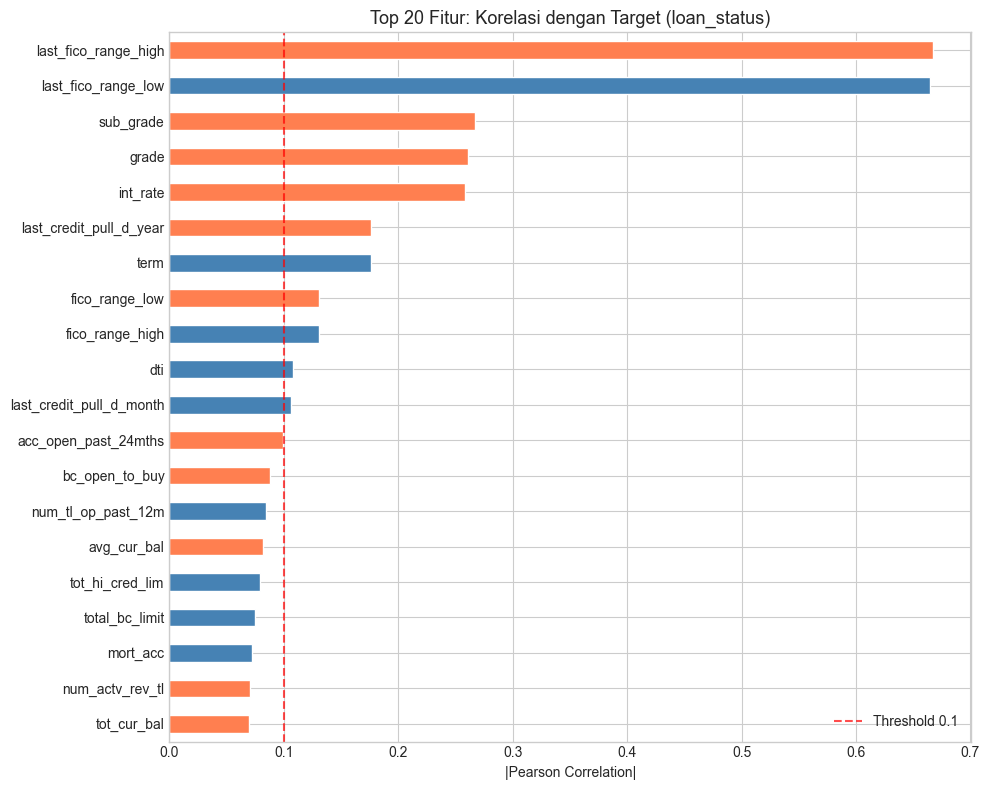

In [51]:
fig, ax = plt.subplots(figsize=(10, 8))
top20_corr = corr_with_target.head(20)
colors = ['steelblue' if v > 0 else 'coral' for v in X[top20_corr.index].corrwith(y).head(20)]
top20_corr.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Fitur: Korelasi dengan Target (loan_status)', fontsize=13)
ax.set_xlabel('|Pearson Correlation|')
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.7, label='Threshold 0.1')
ax.legend()
plt.tight_layout()
plt.savefig('Results/Images/correlation_target.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Korelasi Fitur vs Target:

Dari output, last_fico_range_high dan last_fico_range_low memiliki korelasi tertinggi
(sekitar 0.66-0.67) dan termasuk kategori kuat. Fitur lainnya seperti sub_grade, grade,
dan int_rate berada di kisaran 0.26-0.27 yang termasuk moderat.

Korelasi negatif berarti semakin tinggi nilai fitur maka semakin kecil probabilitas
default. fico_range yang tinggi menunjukkan peminjam lebih kredibel sehingga risiko
default lebih kecil.

Korelasi positif berarti semakin tinggi nilai fitur maka semakin besar risiko default.
int_rate yang tinggi berarti biaya cicilan lebih berat sehingga risiko gagal bayar naik.

Pearson Correlation hanya mendeteksi hubungan linear. Fitur dengan korelasi rendah belum
tentu tidak informatif karena bisa saja memiliki hubungan non-linear yang terlihat
di Mutual Information.

Deteksi Multikolinearitas Antar Fitur.  
Dua fitur dengan korelasi di atas 0.9 mengandung informasi yang hampir sama sehingga salah satu bisa dibuang tanpa kehilangan informasi prediktif.

In [52]:
top30_features = corr_with_target.head(30).index.tolist()
corr_matrix = X[top30_features].corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 4)
            })

if high_corr_pairs:
    print(f'Pasangan fitur dengan korelasi > 0.9: {len(high_corr_pairs)}')
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('Tidak ada pasangan fitur dengan korelasi > 0.9')

Pasangan fitur dengan korelasi > 0.9: 10
           Feature 1           Feature 2  Correlation
last_fico_range_high last_fico_range_low         0.99
           sub_grade               grade         0.98
           sub_grade            int_rate         0.98
               grade            int_rate         0.95
      fico_range_low     fico_range_high         1.00
     tot_hi_cred_lim         tot_cur_bal         0.98
     num_actv_rev_tl num_rev_tl_bal_gt_0         0.98
         funded_amnt           loan_amnt         1.00
         funded_amnt     funded_amnt_inv         1.00
           loan_amnt     funded_amnt_inv         1.00


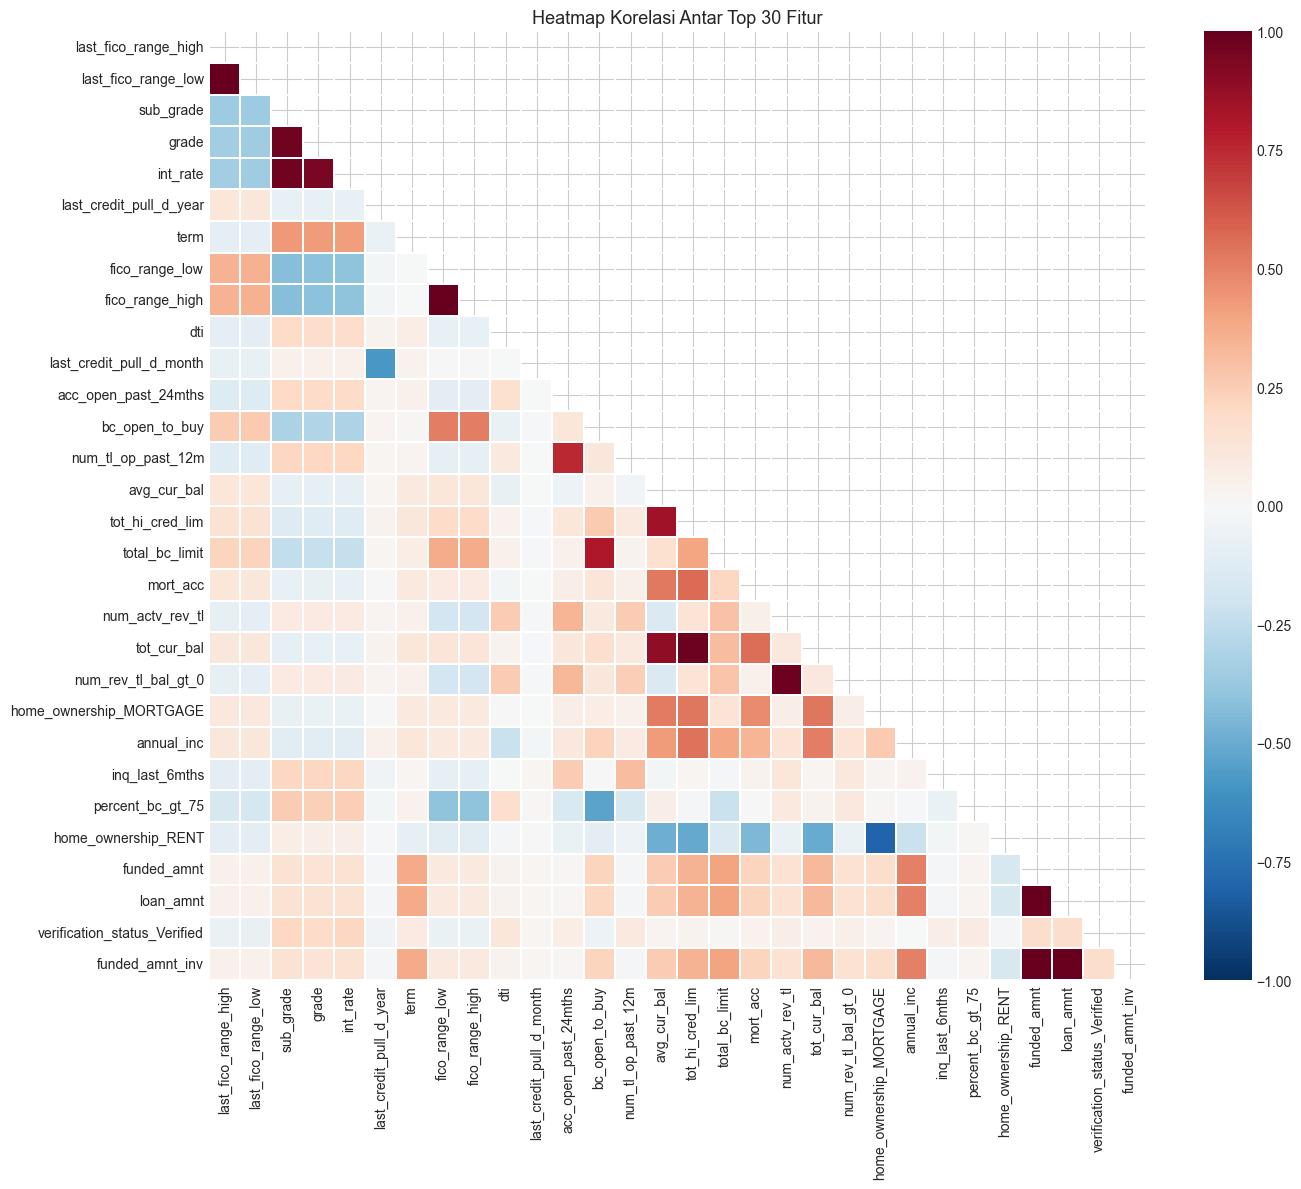

In [53]:
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3
)
ax.set_title('Heatmap Korelasi Antar Top 30 Fitur', fontsize=13)
plt.tight_layout()
plt.savefig('Results/Images/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Heatmap Multikolinearitas:

Area berwarna merah gelap dengan korelasi di atas 0.9 antar fitur menandakan multikolinearitas.
Salah satu dari pasangan tersebut bisa dibuang tanpa kehilangan informasi prediktif yang signifikan.

Pasangan seperti grade dan int_rate umumnya berkorelasi tinggi di dataset Lending Club
karena grade menentukan interest rate secara langsung sebagai bagian dari credit policy platform.

Multikolinearitas tidak menjadi masalah untuk Apriori, namun krusial untuk K-means & DBSCAN.

## 4.3 — Entropy / Mutual Information

Metode 2: Mutual Information berbasis Entropy.  
MI(X;Y) = H(Y) - H(Y|X) di mana H = entropy (ketidakpastian informasi).

Keunggulan vs Korelasi:
- Menangkap hubungan non-linear.
- Bisa untuk tipe data campuran (numerik + kategorik).
- MI = 0 berarti fitur tidak ada hubungan dengan target.
- MI tinggi berarti fitur sangat informatif.

Menggunakan sampel untuk efisiensi komputasi pada dataset besar.

In [54]:
sample_size = min(100_000, len(X))
X_sample = X.sample(n=sample_size, random_state=42)
y_sample = y.loc[X_sample.index]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print('\nTop 20 fitur berdasarkan Mutual Information:')
print(mi_df.head(20).to_string(index=False))


Top 20 fitur berdasarkan Mutual Information:
                   Feature  MI_Score
      last_fico_range_high      0.26
       last_fico_range_low      0.26
                  int_rate      0.04
                 sub_grade      0.04
                     grade      0.04
  last_credit_pull_d_month      0.03
                      term      0.02
               installment      0.02
   last_credit_pull_d_year      0.02
               open_act_il      0.02
               policy_code      0.02
               open_rv_12m      0.02
purpose_debt_consolidation      0.01
     initial_list_status_w      0.01
   home_ownership_MORTGAGE      0.01
            fico_range_low      0.01
           fico_range_high      0.01
       home_ownership_RENT      0.01
               funded_amnt      0.01
              issue_d_year      0.01


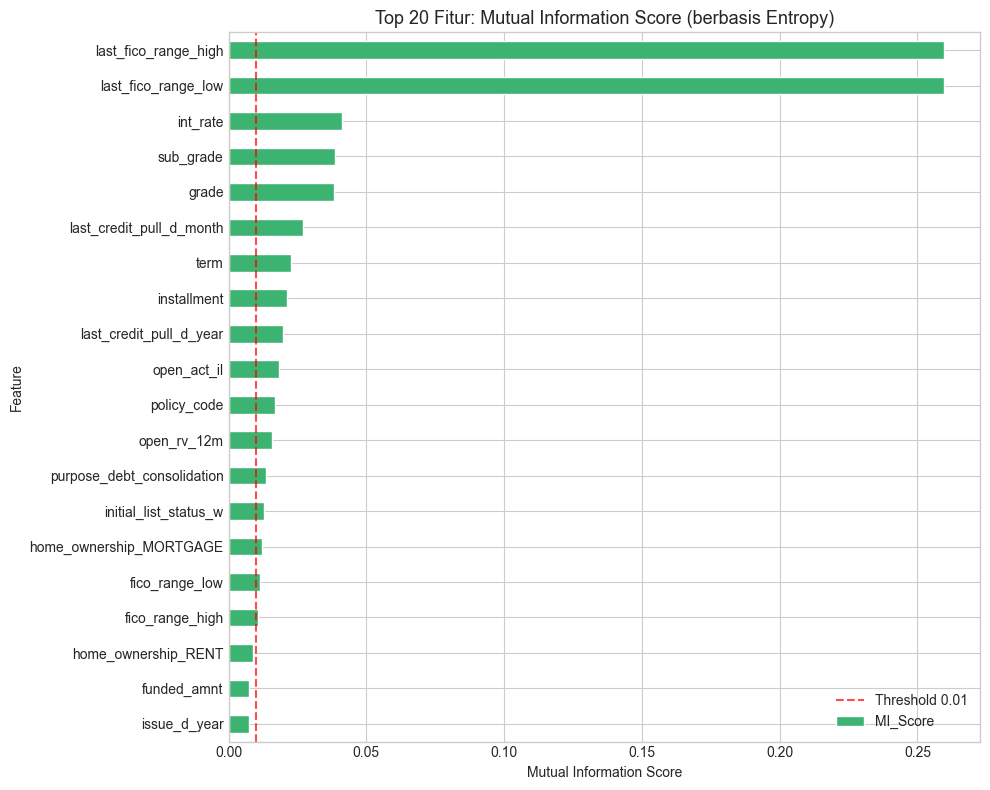

In [55]:
fig, ax = plt.subplots(figsize=(10, 8))
mi_df.head(20).sort_values('MI_Score').plot(
    kind='barh', x='Feature', y='MI_Score',
    ax=ax, color='mediumseagreen', edgecolor='white', legend=False
)
ax.set_title('Top 20 Fitur: Mutual Information Score (berbasis Entropy)', fontsize=13)
ax.set_xlabel('Mutual Information Score')
ax.axvline(x=0.01, color='red', linestyle='--', alpha=0.7, label='Threshold 0.01')
ax.legend()
plt.tight_layout()
plt.savefig('Results/Images/mutual_information.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Mutual Information Score:

MI Score mengukur seberapa banyak informasi yang dibagikan antara fitur dan target.
Nilai 0 berarti fitur sepenuhnya tidak relevan terhadap target.

Fitur dengan MI Score tinggi menangkap hubungan yang mungkin non-linear sekalipun,
yang tidak terdeteksi oleh Pearson Correlation. Perbedaan urutan fitur antara Mutual Information dan Correlation menunjukkan adanya potensi hubungan non-linear dalam dataset.

Fitur dengan MI Score mendekati 0 bisa dipertimbangkan untuk di-drop pada feature selection final karena hampir tidak memberikan informasi prediktif tentang status pinjaman.

## 4.4 — Gabungkan dan Pilih Fitur Final

Gabungkan skor Korelasi dan Mutual Information.  
Setiap skor dinormalisasi ke [0,1] agar bisa dijumlahkan secara adil.  
Combined_Score adalah rata-rata dari keduanya.  
Pendekatan ensemble ini lebih robust daripada mengandalkan satu metode.  

In [56]:
combined_scores = pd.DataFrame({
    'Feature': corr_with_target.index,
    'Abs_Correlation': corr_with_target.values
}).merge(mi_df, on='Feature', how='inner')

combined_scores['Corr_Norm'] = combined_scores['Abs_Correlation'] / combined_scores['Abs_Correlation'].max()
combined_scores['MI_Norm'] = combined_scores['MI_Score'] / combined_scores['MI_Score'].max()
combined_scores['Combined_Score'] = (combined_scores['Corr_Norm'] + combined_scores['MI_Norm']) / 2

combined_scores = combined_scores.sort_values('Combined_Score', ascending=False)
print('Top 20 fitur berdasarkan Combined Score:')
print(combined_scores.head(20)[['Feature', 'Abs_Correlation', 'MI_Score', 'Combined_Score']].to_string(index=False))

Top 20 fitur berdasarkan Combined Score:
                 Feature  Abs_Correlation  MI_Score  Combined_Score
    last_fico_range_high             0.67      0.26            1.00
     last_fico_range_low             0.66      0.26            1.00
               sub_grade             0.27      0.04            0.27
                int_rate             0.26      0.04            0.27
                   grade             0.26      0.04            0.27
                    term             0.18      0.02            0.18
 last_credit_pull_d_year             0.18      0.02            0.17
last_credit_pull_d_month             0.11      0.03            0.13
          fico_range_low             0.13      0.01            0.12
         fico_range_high             0.13      0.01            0.12
                     dti             0.11      0.00            0.09
    acc_open_past_24mths             0.10      0.01            0.09
             installment             0.05      0.02            0.08
 home_o

In [57]:
top_n = 25
selected_features = combined_scores.head(top_n)['Feature'].tolist()

print(f'{top_n} fitur terpilih untuk dataset final:')
for i, feat in enumerate(selected_features, 1):
    row = combined_scores[combined_scores['Feature'] == feat].iloc[0]
    print(f'  {i:2d}. {feat:<40} | Corr={row["Abs_Correlation"]:.4f} | MI={row["MI_Score"]:.4f}')

25 fitur terpilih untuk dataset final:
   1. last_fico_range_high                     | Corr=0.6671 | MI=0.2597
   2. last_fico_range_low                      | Corr=0.6648 | MI=0.2595
   3. sub_grade                                | Corr=0.2670 | MI=0.0387
   4. int_rate                                 | Corr=0.2586 | MI=0.0413
   5. grade                                    | Corr=0.2613 | MI=0.0382
   6. term                                     | Corr=0.1757 | MI=0.0226
   7. last_credit_pull_d_year                  | Corr=0.1762 | MI=0.0196
   8. last_credit_pull_d_month                 | Corr=0.1058 | MI=0.0269
   9. fico_range_low                           | Corr=0.1307 | MI=0.0116
  10. fico_range_high                          | Corr=0.1307 | MI=0.0107
  11. dti                                      | Corr=0.1079 | MI=0.0049
  12. acc_open_past_24mths                     | Corr=0.0992 | MI=0.0068
  13. installment                              | Corr=0.0514 | MI=0.0214
  14. home_o

In [58]:
print(f"Berhasil mengambil {len(df_acc_clean_for_apriori.columns)} kolom.")
print(df_acc_clean_for_apriori.columns.tolist())

if 'loan_status' in df_acc_clean_for_apriori:
    print("ada")


Berhasil mengambil 115 kolom.
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'loan_status', 'pymnt_plan', 'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', '

In [59]:
# Kolom bin yang dibuat di Langkah 3.4
bin_cols = ['int_rate_bin', 'dti_bin', 'income_bin', 'loan_amnt_bin']

auto_selected = [c for c in selected_features if c in df_acc_clean_for_apriori.columns]

# home_ownership sudah di-OHE sebelumnya → ambil semua kolom hasil OHE-nya
home_ohe_cols = [c for c in df_acc_clean_for_apriori.columns if c.startswith('home_ownership_')]

features_to_keep = auto_selected + bin_cols + home_ohe_cols + ['loan_status']

final_columns = [c for c in features_to_keep if c in df_acc_clean_for_apriori.columns]
df_selection_clean_for_apriori = df_acc_clean_for_apriori[final_columns].copy()

print(f"Berhasil mengambil {len(df_selection_clean_for_apriori.columns)} kolom.")
print("Kolom home_ownership yang tersedia:", home_ohe_cols)
print("Kolom yang tersedia sekarang:", df_selection_clean_for_apriori.columns.tolist())

Berhasil mengambil 35 kolom.
Kolom home_ownership yang tersedia: ['home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT']
Kolom yang tersedia sekarang: ['last_fico_range_high', 'last_fico_range_low', 'sub_grade', 'int_rate', 'grade', 'term', 'last_credit_pull_d_year', 'last_credit_pull_d_month', 'fico_range_low', 'fico_range_high', 'dti', 'acc_open_past_24mths', 'installment', 'home_ownership_MORTGAGE', 'bc_open_to_buy', 'num_tl_op_past_12m', 'home_ownership_RENT', 'avg_cur_bal', 'tot_hi_cred_lim', 'inq_last_6mths', 'funded_amnt', 'total_bc_limit', 'mort_acc', 'num_actv_rev_tl', 'loan_amnt', 'int_rate_bin', 'dti_bin', 'income_bin', 'loan_amnt_bin', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_status']


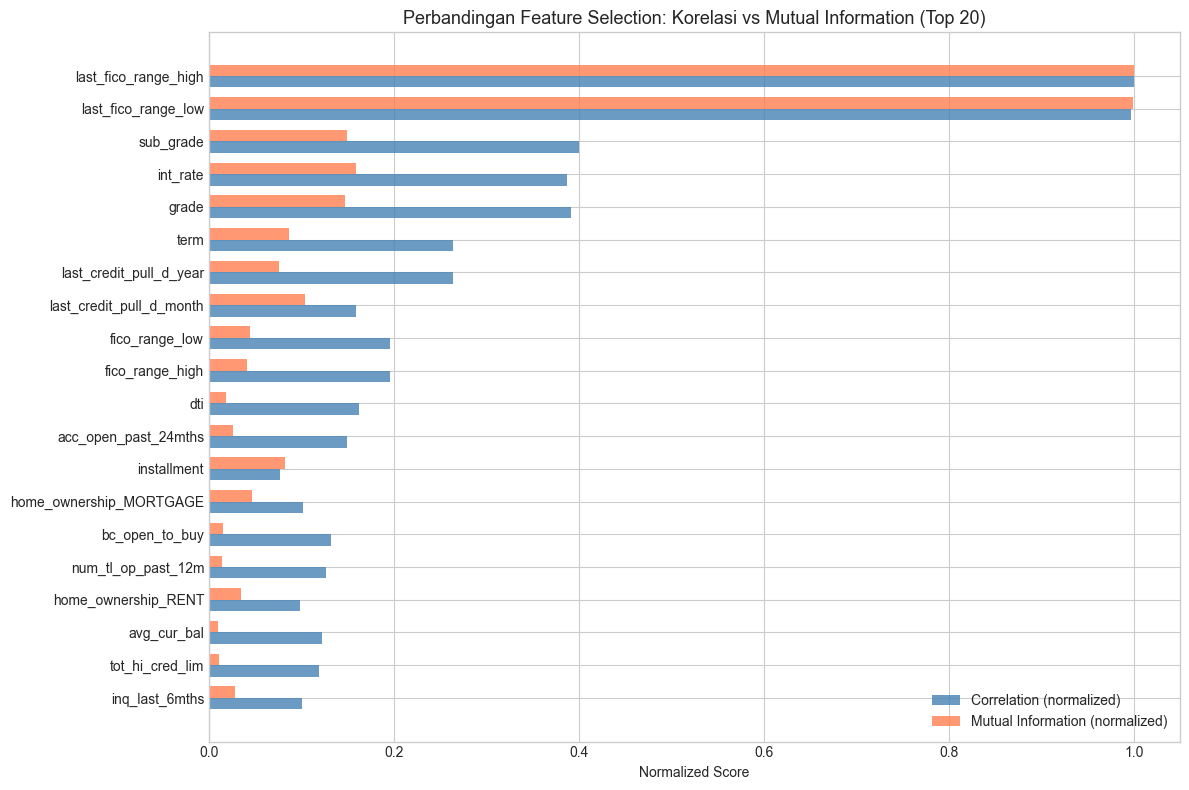

In [60]:
plot_df = combined_scores.head(20).sort_values('Combined_Score')
# df_for_apriori = df_acc_clean[features_to_keep].copy()

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(plot_df))
width = 0.35

ax.barh(x - width/2, plot_df['Corr_Norm'], width, label='Correlation (normalized)', color='steelblue', alpha=0.8)
ax.barh(x + width/2, plot_df['MI_Norm'], width, label='Mutual Information (normalized)', color='coral', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(plot_df['Feature'])
ax.set_xlabel('Normalized Score')
ax.set_title('Perbandingan Feature Selection: Korelasi vs Mutual Information (Top 20)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('Results/Images/feature_selection_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

Insight Perbandingan Korelasi vs Mutual Information:

Fitur yang konsisten tinggi di kedua metode merupakan kandidat terkuat untuk dimasukkan ke
model karena keduanya mengkonfirmasi relevansi dari sudut pandang linear dan non-linear.

Fitur yang tinggi di MI tetapi rendah di Korelasi mengindikasikan kemungkinan hubungan non-linear
dengan target seperti  outlier, interaksi threshold atau pola U-shape. Fitur ini sering dilewatkan
jika hanya menggunakan korelasi linear saja.

Fitur yang tinggi di Korelasi tetapi rendah di MI umumnya memiliki hubungan linear yang
kuat namun tidak banyak menambah informasi unik di luar fitur lain.

Strategi ensemble yang menggabungkan kedua metode lebih robust dibanding mengandalkan
satu metode saja karena masing-masing memiliki blind spot yang berbeda.

---
# Persiapan Data untuk Apriori

Tujuan: Mengubah data accepted dan rejected menjadi format biner (0/1) yang siap diproses oleh algoritma Apriori.

Dua output yang dihasilkan:
- **Langkah 1** — Binning & OHE data Accepted → `clean_for_apriori_accepted.csv`
- **Langkah 2** — Binning & OHE data Rejected → `clean_for_apriori_rejected_sparse.npz` + `clean_for_apriori_rejected_columns.json`

Catatan: Binning numerik menggunakan `pd.qcut` (kuantil 3 bagian sama besar) agar distribusi tiap bin seimbang.
Binning kategorik menggunakan `pd.cut` dengan batas berbasis domain (standar industri kredit).

## Langkah 1 — Binning & OHE Data Accepted

Menggunakan `df_selection_clean_for_apriori` (hasil seleksi fitur) yang sudah bersih.
Fitur kategori langsung di-OHE, fitur numerik di-bin terlebih dahulu menggunakan
`pd.qcut` (quantile-based) agar tiap bin berisi jumlah data yang proporsional.

### Justifikasi Pemilihan Fitur untuk Binning — Accepted

Fitur dipilih untuk di-bin jika memenuhi dua syarat: **(1) bertipe kontinu** sehingga perlu diskretisasi agar bisa masuk Apriori, dan **(2) secara domain kredit berkaitan langsung dengan kemampuan atau risiko bayar peminjam**.

**Dipilih untuk di-bin (numerik kontinu → qcut 3 kategori):**

| Fitur | Alasan |
|---|---|
| `loan_amnt` | Ukuran pinjaman — semakin besar, semakin berat beban cicilan |
| `annual_inc` | Proksi kemampuan bayar — pendapatan rendah meningkatkan risiko gagal bayar |
| `int_rate` | Ringkasan risiko dari platform — bunga tinggi = peminjam berisiko tinggi |
| `dti` | Standar industri kredit — rasio utang terhadap pendapatan yang sudah ada |
| `installment` | Beban cicilan nyata per bulan setelah memperhitungkan tenor dan bunga |
| `last_fico_range_low` | Kondisi kredit peminjam *selama* pinjaman berlangsung |
| `fico_range_low` | Baseline kelayakan kredit saat pengajuan |

**Dipilih langsung OHE (sudah kategorik, tidak perlu di-bin):**

| Fitur | Alasan |
|---|---|
| `grade`, `sub_grade` | Sudah kategorik dengan urutan natural — diambil dari snapshot sebelum ordinal encoding |
| `term` | Hanya 2 nilai (36/60 bulan) — dikonversi ke string sebelum OHE agar terbaca sebagai kategori |
| `loan_status` | Target variable — diikutkan agar Apriori bisa membentuk rules seperti *grade_A → Fully Paid* |
| `home_ownership_*` | Sudah berbentuk biner dari proses encoding sebelumnya — langsung dipakai tanpa OHE ulang |

**Tidak dipilih:**

| Fitur | Alasan |
|---|---|
| `last_fico_range_high`, `fico_range_high` | Redundan dengan versi `_low` — korelasi >0.99, tidak menambah informasi baru |
| `issue_d_*`, `earliest_cr_line_*`, `last_credit_pull_d_*` | Fitur tanggal — tidak relevan untuk pattern mining karakteristik peminjam |
| `open_acc`, `pub_rec`, `delinq_2yrs` | Zero-inflated — mayoritas bernilai 0, binning tidak menghasilkan kategori yang informatif |
| `revol_bal`, `revol_util`, `total_acc` | Informasi sudah tercakup oleh `dti` dan `fico` sebagai agregasi risiko |
| `emp_length` | Informasi stabilitas kerja relevan namun kalah informatif dibanding FICO dan DTI untuk pattern Apriori |
| `verification_status_*`, `purpose_*`, `disbursement_method_*`, `initial_list_status_*` | Sudah berbentuk biner dari proses encoding sebelumnya — tidak perlu di-bin ulang |

In [61]:
# Ambil index setelah dropna loan_status_binary
# Semua snapshot di-reindex ke index yang sama agar tidak mismatch baris
idx = df_selection_clean_for_apriori.index

# ── Kolom kategori ────────────────────────────────────────────────────────
# grade & sub_grade: pakai snapshot string sebelum ordinal encoding
#   → OHE menghasilkan grade_A, grade_B, ... yang bermakna
# term: sudah numerik (36/60) setelah cleaning → konversi ke string dulu
#   agar pd.get_dummies membaca sebagai kategori, bukan angka
# home_ownership: sudah OHE sebelumnya → kolom biner langsung dipakai
# loan_status: target variable diikutkan agar rules bisa mengandung outcome
# int_rate_bin, dti_bin, income_bin: kolom bin dari binning Langkah 3.4

cat_features_acc = ['int_rate_bin', 'dti_bin', 'income_bin', 'loan_status']
cat_features_acc = [c for c in cat_features_acc if c in df_selection_clean_for_apriori.columns]

# Tambahkan kolom home_ownership OHE (home_ownership_OWN, home_ownership_RENT, dst)
home_ohe_cols = [c for c in df_selection_clean_for_apriori.columns if c.startswith('home_ownership_')]
cat_features_acc += home_ohe_cols

df_apriori_acc = df_selection_clean_for_apriori[cat_features_acc].copy()

# Tambahkan grade & sub_grade dari snapshot string
if grade_before_encode is not None:
    df_apriori_acc['grade'] = grade_before_encode.reindex(idx)
if sub_grade_before_encode is not None:
    df_apriori_acc['sub_grade'] = sub_grade_before_encode.reindex(idx)

# Tambahkan term dari snapshot — konversi ke string agar OHE menghasilkan term_36, term_60
if 'term' in df_selection_clean_for_apriori.columns:
    df_apriori_acc['term'] = df_selection_clean_for_apriori['term'].reindex(idx).astype(str)

# ── Kolom numerik → di-bin dengan qcut (3 kuantil sama besar) ────────────
# Semua dari snapshot_before_scale (nilai sebelum StandardScaler, satuan asli)
# Khusus annual_inc dari annual_inc_before_log (nilai sebelum log transform)
num_features_acc = {
    'last_fico_range_low' : snapshot_before_scale.get('last_fico_range_low'),
    'fico_range_low'      : snapshot_before_scale.get('fico_range_low'),
    'loan_amnt'           : snapshot_before_scale.get('loan_amnt'),
    'installment'         : snapshot_before_scale.get('installment'),
    'annual_inc'          : annual_inc_before_log,
}

for col, series in num_features_acc.items():
    if series is not None:
        df_apriori_acc[col + '_bin'] = pd.qcut(
            series.reindex(idx), q=3,
            labels=['Low', 'Medium', 'High'], duplicates='drop'
        )

# ── OHE → format biner 0/1 ───────────────────────────────────────────────
# uint8: hemat memori 8x dibanding int64 (nilai 0/1 cukup dalam 1 byte)
df_apriori_acc_ready = pd.get_dummies(df_apriori_acc).astype('uint8')
df_apriori_acc_ready = df_apriori_acc_ready.dropna()

print(f'[Accepted Apriori] Shape  : {df_apriori_acc_ready.shape}')
print(f'[Accepted Apriori] Kolom  : {df_apriori_acc_ready.shape[1]} kolom biner')
print(f'[Accepted Apriori] Memory : {df_apriori_acc_ready.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_apriori_acc_ready.head(3)

[Accepted Apriori] Shape  : (1348100, 90)
[Accepted Apriori] Kolom  : 90 kolom biner
[Accepted Apriori] Memory : 165.9 MB


,home_ownership_MORTGAGE,home_ownership_MORTGAGE,home_ownership_RENT,home_ownership_RENT,home_ownership_MORTGAGE,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,home_ownership_RENT,int_rate_bin_Very Low (<8%),int_rate_bin_Low (8-12%),int_rate_bin_Medium (12-16%),int_rate_bin_High (16-20%),int_rate_bin_Very High (>20%),dti_bin_Very Low (<10),dti_bin_Low (10-20),dti_bin_Medium (20-30),dti_bin_High (30-40),dti_bin_Very High (>40),income_bin_Low (<30K),income_bin_Lower-Mid (30-60K),income_bin_Mid (60-100K),income_bin_High (100-200K),...,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,term_36,term_60,last_fico_range_low_bin_Low,last_fico_range_low_bin_Medium,last_fico_range_low_bin_High,fico_range_low_bin_Low,fico_range_low_bin_Medium,fico_range_low_bin_High,loan_amnt_bin_Low,loan_amnt_bin_Medium,loan_amnt_bin_High,installment_bin_Low,installment_bin_Medium,installment_bin_High,annual_inc_bin_Low,annual_inc_bin_Medium,annual_inc_bin_High
0,1,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0
1,1,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,1,0
2,1,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0


## Langkah 2 — Binning & OHE Data Rejected (Sparse Matrix)

`df_rej_clean` memiliki ~27 juta baris. OHE dengan format dense (`int64`) menyebabkan
MemoryError karena membutuhkan alokasi >10 GB RAM sekaligus.

Solusi: gunakan **sparse matrix** dari `scipy.sparse`. Format ini hanya menyimpan
posisi nilai `1` dan mengabaikan nilai `0` — cocok untuk data biner Apriori yang
mayoritas nilainya 0. Penghematan memori mencapai 10–50x dibanding dense array.

Output disimpan dalam dua file:
- `.npz` — sparse matrix (format scipy, hemat disk dan RAM)
- `.json` — nama kolom (untuk rekonstruksi saat menjalankan Apriori)

### Justifikasi Pemilihan Fitur untuk Binning — Rejected

Dataset rejected hanya memiliki 9 kolom sejak awal — jauh lebih terbatas dibanding accepted.
Fitur dipilih jika tersedia, bersih, dan relevan terhadap keputusan penolakan kredit.

**Dipilih untuk di-bin:**

| Fitur | Alasan |
|---|---|
| `Amount Requested` | Satu-satunya informasi skala pinjaman yang tersedia — nominal terlalu besar adalah alasan penolakan umum |
| `Debt-To-Income Ratio` | Sinyal penolakan paling langsung — Lending Club menggunakan DTI sebagai kriteria penolakan otomatis |
| `Employment Length` | Mencerminkan stabilitas pendapatan — employment rendah meningkatkan risiko di mata platform. Sudah dikonversi ke angka 0–10 pada tahap cleaning |

**Tidak dipilih:**

| Fitur | Alasan |
|---|---|
| `Loan Title` | Teks bebas — ribuan nilai unik, setelah OHE menghasilkan ribuan kolom biner yang hampir semua bernilai 0 |
| `Risk Score` | Dibuang pada tahap cleaning — >50% missing, tidak bisa diimputasi secara andal |
| `Zip Code` | Ribuan nilai unik — hasil OHE tidak informatif dan memberatkan memori |
| `State` | 50 nilai unik — menambah kolom tanpa insight signifikan tentang keputusan kredit |
| `Application Date` | Tanggal — tidak relevan untuk pattern mining karakteristik peminjam |
| `Policy Code` | Nilai konstan (semua = 1) — tidak ada variasi, tidak memberikan informasi apapun untuk Apriori |

In [62]:
from scipy.sparse import csr_matrix, save_npz
import json as _json

# ── Langkah 1: Binning — pakai full data df_rej_clean (27 juta baris) ────
# Tidak ada sampling: seluruh data diproses
# Memory aman karena binning hanya membuat 1 kolom kategorik per iterasi
num_features_rej = ['Amount Requested', 'Debt-To-Income Ratio']

df_apriori_rej = pd.DataFrame(index=df_rej_clean.index)

# Binning numerik dengan qcut (3 kuantil sama besar)
for col in num_features_rej:
    if col in df_rej_clean.columns:
        df_apriori_rej[col + '_bin'] = pd.qcut(
            df_rej_clean[col], q=3,
            labels=['Low', 'Medium', 'High'], duplicates='drop'
        )

# Binning Employment Length dengan cut berbasis domain
# 0-1: Junior (belum stabil), 2-5: Mid, 6-10: Senior (stabil)
if 'Employment Length' in df_rej_clean.columns:
    df_apriori_rej['Employment Length_bin'] = pd.cut(
        df_rej_clean['Employment Length'],
        bins=[-1, 1, 5, 10],
        labels=['Junior (0-1yr)', 'Mid (2-5yr)', 'Senior (6-10yr)']
    )

df_apriori_rej = df_apriori_rej.dropna()
print(f'Total baris setelah dropna : {len(df_apriori_rej):,}')
print(f'Fitur yang digunakan       : {df_apriori_rej.columns.tolist()}')

# ── Langkah 2: OHE dengan sparse=True ────────────────────────────────────
# sparse=True: pandas tidak membuat dense array → tidak ada alokasi memori besar
df_ohe_rej = pd.get_dummies(df_apriori_rej, sparse=True)

column_names_rej = df_ohe_rej.columns.tolist()
print(f'Jumlah kolom biner         : {len(column_names_rej)}')
print(f'Kolom                      : {column_names_rej}')

# ── Langkah 3: Konversi ke scipy CSR sparse matrix ───────────────────────
# CSR (Compressed Sparse Row): format optimal untuk row-wise access (Apriori)
sparse_rej = csr_matrix(df_ohe_rej.astype('uint8'))
density = sparse_rej.nnz / (sparse_rej.shape[0] * sparse_rej.shape[1])
print(f'Shape sparse matrix        : {sparse_rej.shape}')
print(f'Memory (data saja)         : {sparse_rej.data.nbytes / 1e6:.1f} MB')
print(f'Density                    : {density:.4f} ({density*100:.2f}% nilai non-zero)')

# ── Langkah 4: Simpan ─────────────────────────────────────────────────────
save_npz('../Datasets/Cleaning/Phase 3/clean_for_apriori_rejected_sparse.npz', sparse_rej)

with open('../Datasets/Cleaning/Phase 3/clean_for_apriori_rejected_columns.json', 'w') as f:
    _json.dump(column_names_rej, f)

print()
print('Saved: clean_for_apriori_rejected_sparse.npz')
print('Saved: clean_for_apriori_rejected_columns.json')

Total baris setelah dropna : 27,490,787
Fitur yang digunakan       : ['Amount Requested_bin', 'Debt-To-Income Ratio_bin', 'Employment Length_bin']
Jumlah kolom biner         : 9
Kolom                      : ['Amount Requested_bin_Low', 'Amount Requested_bin_Medium', 'Amount Requested_bin_High', 'Debt-To-Income Ratio_bin_Low', 'Debt-To-Income Ratio_bin_Medium', 'Debt-To-Income Ratio_bin_High', 'Employment Length_bin_Junior (0-1yr)', 'Employment Length_bin_Mid (2-5yr)', 'Employment Length_bin_Senior (6-10yr)']
Shape sparse matrix        : (27490787, 9)
Memory (data saja)         : 82.5 MB
Density                    : 0.3333 (33.33% nilai non-zero)

Saved: clean_for_apriori_rejected_sparse.npz
Saved: clean_for_apriori_rejected_columns.json


---
# Simpan Hasil

In [63]:
# ── Accepted: simpan sebagai CSV (ukuran ~1.3 juta baris, masih manageable) ──
df_apriori_acc_ready.to_csv('../Datasets/Cleaning/Phase 3/clean_for_apriori_accepted.csv', index=False)
print(f'Saved: clean_for_apriori_accepted.csv       — {df_apriori_acc_ready.shape}')

# ── Rejected: sudah disimpan sebagai .npz + .json di Langkah 2 ─────────────
# File: clean_for_apriori_rejected_sparse.npz
#       clean_for_apriori_rejected_columns.json
print(f'Saved: clean_for_apriori_rejected_sparse.npz — {sparse_rej.shape} (sparse)')
print(f'Saved: clean_for_apriori_rejected_columns.json — {len(column_names_rej)} kolom')

print()
print('Semua file berhasil disimpan.')

Saved: clean_for_apriori_accepted.csv       — (1348100, 90)
Saved: clean_for_apriori_rejected_sparse.npz — (27490787, 9) (sparse)
Saved: clean_for_apriori_rejected_columns.json — 9 kolom

Semua file berhasil disimpan.


---
# Summary Report — Preprocessing Pipeline

In [64]:
print('=' * 70)
print('PREPROCESSING SUMMARY REPORT — LENDING CLUB LOAN DATASET')
print('=' * 70)

print('\n[1] EXPLORATORY DATA ANALYSIS')
print(f'    df_acc raw             : {df_acc.shape[0]:>10,} rows x {df_acc.shape[1]} cols')
print(f'    df_rej raw             : {df_rej.shape[0]:>10,} rows x {df_rej.shape[1]} cols')
print(f'    df_acc kolom kategorik : {len(df_acc.select_dtypes(include="object").columns)}')
print(f'    df_acc kolom numerik   : {len(df_acc.select_dtypes(include="number").columns)}')

print('\n[2] DATA CLEANING')
print(f'    Kolom di-drop (>50% missing)   : {len(cols_to_drop_missing)}')
print(f'    Kolom di-drop (non-informatif) : {len(cols_to_drop_manual)}')
print(f'    Kolom di-drop (leaky)          : {len(leaky_cols)}')
print(f'    Kolom skewed di-capping        : {len(skewed_cols)}')

print('\n[3] DATA TRANSFORMATION')
print(f'    Log transform diterapkan pada  : {log_transform_cols}')
print(f'    Kolom di-OHE                   : {len(ohe_cols)}')

print('\n[4] FEATURE SELECTION')
print(f'    Total fitur setelah preprocessing : {X.shape[1]}')
print(f'    Fitur terpilih (top {top_n})          : {len(selected_features)}')
print(f'    Metode: Pearson Correlation + Mutual Information')

print('\n[5] PERSIAPAN DATA APRIORI')
print(f'    Accepted — format  : CSV (dense uint8)')
print(f'    Accepted — shape   : {df_apriori_acc_ready.shape}')
print(f'    Accepted — memory  : {df_apriori_acc_ready.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'    Rejected — format  : sparse matrix (.npz)')
print(f'    Rejected — shape   : {sparse_rej.shape}')
print(f'    Rejected — memory  : {sparse_rej.data.nbytes / 1e6:.1f} MB (data saja)')
print(f'    Rejected — kolom   : {len(column_names_rej)} kolom biner')

print('\n[6] OUTPUT FILES')
print('    clean_for_apriori_accepted.csv           → Apriori accepted (CSV)')
print('    clean_for_apriori_rejected_sparse.npz    → Apriori rejected (sparse matrix)')
print('    clean_for_apriori_rejected_columns.json  → nama kolom rejected')

print('\n[7] CARA LOAD REJECTED DI NOTEBOOK APRIORI')
print('    from scipy.sparse import load_npz')
print('    import json')
print('    sparse_rej = load_npz("clean_for_apriori_rejected_sparse.npz")')
print('    with open("clean_for_apriori_rejected_columns.json") as f:')
print('        cols = json.load(f)')
print('    df_rej = pd.DataFrame.sparse.from_spmatrix(sparse_rej, columns=cols)')

print('\n[8] CLASS IMBALANCE — df_acc')
y_final = df_acc_clean['loan_status_binary'].astype(int)
print(f'    Fully Paid (0) : {(y_final==0).sum():,} ({(y_final==0).mean()*100:.1f}%)')
print(f'    Default    (1) : {(y_final==1).sum():,} ({(y_final==1).mean()*100:.1f}%)')
print(f'    Catatan: min_support Apriori disarankan >= 0.05')

print()
print('=' * 70)
print('Preprocessing pipeline selesai.')
print('=' * 70)

PREPROCESSING SUMMARY REPORT — LENDING CLUB LOAN DATASET

[1] EXPLORATORY DATA ANALYSIS
    df_acc raw             :  2,260,701 rows x 151 cols
    df_rej raw             : 27,648,741 rows x 9 cols
    df_acc kolom kategorik : 38
    df_acc kolom numerik   : 113

[2] DATA CLEANING
    Kolom di-drop (>50% missing)   : 44
    Kolom di-drop (non-informatif) : 5
    Kolom di-drop (leaky)          : 12
    Kolom skewed di-capping        : 39

[3] DATA TRANSFORMATION
    Log transform diterapkan pada  : ['annual_inc']
    Kolom di-OHE                   : 5

[4] FEATURE SELECTION
    Total fitur setelah preprocessing : 104
    Fitur terpilih (top 25)          : 25
    Metode: Pearson Correlation + Mutual Information

[5] PERSIAPAN DATA APRIORI
    Accepted — format  : CSV (dense uint8)
    Accepted — shape   : (1348100, 90)
    Accepted — memory  : 165.9 MB
    Rejected — format  : sparse matrix (.npz)
    Rejected — shape   : (27490787, 9)
    Rejected — memory  : 82.5 MB (data saja)
    Rej